# Refactored AI Patent Quality Assessment Notebook

In [ ]:
import warnings
warnings.filterwarnings('ignore')

# Install required packages first
!pip -q install imbalanced-learn xgboost statsmodels python-louvain

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

pd.set_option('display.max_columns', None)

In [ ]:
# Display all columns of the dataframe
pd.set_option('display.max_columns', None)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = "/content/drive/MyDrive/WorkMarch26/DATA/AI18_20.csv"

In [ ]:
#Read AI patent data and convert into data frame
import pandas as pd
df = pd.read_csv(file_path,skiprows=0, encoding='latin1', on_bad_lines='warn')
df.head()

,Publication Number,Application Date,Publication Date,Assignee/Applicant,Claims Count,Assignee Count,Inventor Count,Publication Country Code,Count of Cited Refs - Patent,Count of Cited Refs - Non-patent,Count of Citing Patents,DWPI Count of Family Members,DWPI Count of Family Countries/Regions,Related Applications,IPC - Current,CPC - Current,Priority Number,Priority Date,Priority Date - DWPI,DWPI Family Members,DWPI Family Members Dead/Alive,Dead/Alive,Opposition (EP),License (EP),Strategic Importance,Probability of Grant,Combined Patent Impact,Assignee - Original - Country/Region,Application Number,Priority Year(s),Application Year,Publication Year,Application Month,Publication Month,Citing Patents,Citing Pat 1st Assignee,Cited Refs - Patent,Cited Pat 1st Assignee,Cited Refs - Non-patent,Cited Non-patents-DOI,Inventor,IPC Class,IPC Subclass,CPC Class,Priority Country/Region,Attorney/Agent,Examiner,Designated States,Assignee - Original,Assignee - Original w/address,Assignee - Original - Country/Region (Original Language),Inventor - Original,Inventor - w/address,Application Country/Region,Priority Country/Region - DWPI,Ultimate Parent
0,US10880328B2,2018-11-16,2020-12-29,"ACCENTURE GLOBAL SOLUTIONS LIMITED,Dublin,IE",20.0,2,2,US,17,0,5,4.0,45.0,US16193956A | 2018-11-16,H04L002906 | G06F002156 | G06N000304 | G06N000308,G06F0021561 | G06F0021562 | G06F0021566 | G06N...,US16193956A,2018-11-16,2018-11-16,EP3654217A1 | US20200162483A1 | US10880328B2 |...,EP3654217A1 Alive | US20200162483A1 Alive | US...,Alive,NaN,NaN,4.36,100.0,21.20,"ACCENTURE GLOBAL SOLUTIONS LIMITED,IE",US16193956A,2018,2018,2020.0,11,12.0,US11977633B2 | US12014140B2 | US12056241B2 | U...,ACRONIS INT GMBH | ACCENTURE GLOBAL SOLUTIONS ...,KR1863615B1 | US10133865B1 | US20120084859A1 |...,ESTSOFT CORP | SYMANTEC CORP | MICROSOFT CORP ...,NaN,NaN,"Farhady, Nahid | Ben Salem, Malek",H04 | G06,H04L | G06F | G06N,G06 | H04,US,"Mannava & Kang, P.C.","Schwartz, Darren B - 2435",NaN,ACCENTURE GLOBAL SOLUTIONS LIMITED,"ACCENTURE GLOBAL SOLUTIONS LIMITED,Dublin,IE","ACCENTURE GLOBAL SOLUTIONS LIMITED,IE","Farhady, Nahid | Ben Salem, Malek","Farhady Nahid|Falls Church, VA, US | Ben Salem...",US,US,ACCENTURE LTD.
1,US10880299B2,2018-05-30,2020-12-29,"Jumio Corporation,Palo Alto,CA,US",24.0,2,3,US,15,2,1,5.0,134.0,US15993366A | 2018-05-30,G06V003040 | H04L002906 | G06N002000,G06V003040 | G06N002000 | G06V003019133 | G06V...,US15993366A,2018-05-30,2018-05-30,US20190372968A1 | WO2019231698A1 | WO201923169...,US20190372968A1 Alive | WO2019231698A1 Dead | ...,Alive,NaN,NaN,6.03,100.0,21.20,"Jumio Corporation,US",US15993366A,2018,2018,2020.0,5,12.0,US20210224563A1,JUMIO CORP,EP2784734A1 | US20020194178A1 | US20090152357A...,WAL MART STORES INC | TACIT KNOWLEDGE SYSTEMS ...,"Jumio Corporation, International Search Report...",NaN,"Balogh, Attila | Hochrieser, Reinhard | Rogoja...",G06 | H04,G06V | H04L | G06N,G06 | H04,US,"Morgan, Lewis & Bockius LLP","Abyaneh, Ali S - 2437 / Tafaghodi, Zoha Piyade...",NaN,Jumio Corporation,"Jumio Corporation,Palo Alto,CA,US","Jumio Corporation,US","Balogh, Attila | Hochrieser, Reinhard | Rogoja...","Balogh Attila|Vienna, AT | Hochrieser Reinhard...",US,US,ANT GROUP (ANT FINANCIAL SERVICES)
2,US10880186B2,2019-04-01,2020-12-29,"Cisco Technology Inc.,San Jose,CA,US",20.0,2,4,US,15,1,1,2.0,1.0,US16371556A | 2019-04-01,G06N002000 | H04L001246 | H04L004524 | H04L001228,H04L00124641 | G06N002000 | H04L00124633 | H04...,US16371556A,2019-04-01,2019-04-01,US20200313979A1 | US10880186B2,US20200313979A1 Alive | US10880186B2 Alive,Alive,NaN,NaN,12.75,100.0,12.11,"Cisco Technology Inc.,US",US16371556A,2019,2019,2020.0,4,12.0,US11552886B2,CISCO TECH INC,US20020038366A1 | US20070083513A1 | US20100138...,NEC CORP | | | INFOSYS LTD | HEWLETT PACKARD...,âWhat is Software-Defined WAN (or SD-WAN or ...,NaN,"Kumaran, Vikram | Vasseur, Jean-Philippe | Mer...",G06 | H04,G06N | H04L,H04 | G06,US,"Behmke Innovation Group LLC | Heywood, Kenneth...","Lee, Gil H. - 2446",NaN

In [ ]:
#Read AI patent data and convert into data frame
file_path = "/content/drive/MyDrive/WorkMarch26/DATA/AI_21.csv"
df_unseen1=pd.read_csv(file_path,skiprows=0, encoding='latin1', on_bad_lines='warn')
file_path = "/content/drive/MyDrive/WorkMarch26/DATA/AI_01_22_10_22.csv"
df_unseen2=pd.read_csv(file_path,skiprows=0, encoding='latin1', on_bad_lines='warn')
file_path = "/content/drive/MyDrive/WorkMarch26/DATA/AI_11_22_06_23.csv"
df_unseen3=pd.read_csv(file_path,skiprows=0, encoding='latin1', on_bad_lines='warn')
file_path = "/content/drive/MyDrive/WorkMarch26/DATA/AI_07_23_01_24.csv"
df_unseen4=pd.read_csv(file_path,skiprows=0, encoding='latin1', on_bad_lines='warn')
file_path = "/content/drive/MyDrive/WorkMarch26/DATA/AI_02_24_07_24.csv"
df_unseen5=pd.read_csv(file_path,skiprows=0, encoding='latin1', on_bad_lines='warn')
file_path = "/content/drive/MyDrive/WorkMarch26/DATA/AI_08_24_12_24.csv"
df_unseen6=pd.read_csv(file_path,skiprows=0, encoding='latin1', on_bad_lines='warn')
df_unseen=pd.concat([df_unseen1,df_unseen2,df_unseen3,df_unseen4,df_unseen5,df_unseen6,])
df_unseen

,Publication Number,Application Date,Publication Date,Assignee/Applicant,Claims Count,Assignee Count,Inventor Count,Publication Country Code,Count of Cited Refs - Patent,Count of Cited Refs - Non-patent,Count of Citing Patents,DWPI Count of Family Members,DWPI Count of Family Countries/Regions,Related Applications,IPC - Current,CPC - Current,Priority Number,Priority Date,Priority Date - DWPI,DWPI Family Members,DWPI Family Members Dead/Alive,Dead/Alive,Opposition (EP),License (EP),Strategic Importance,Probability of Grant,Combined Patent Impact,Assignee - Original - Country/Region,Application Number,Priority Year(s),Application Year,Publication Year,Application Month,Publication Month,Citing Patents,Citing Pat 1st Assignee,Cited Refs - Patent,Cited Pat 1st Assignee,Cited Refs - Non-patent,Cited Non-patents-DOI,Inventor,IPC Class,IPC Subclass,CPC Class,Priority Country/Region,Attorney/Agent,Examiner,Designated States,Assignee - Original,Assignee - Original w/address,Assignee - Original - Country/Region (Original Language),Inventor - Original,Inventor - w/address,Application Country/Region,Priority Country/Region - DWPI,Ultimate Parent
0,US11212946B2,2019-09-18,2021-12-28,"BAIDU USA LLC,Sunnyvale,CA,US",16.0,2,2,US,10,0,0,4.0,2.0,US16575368A | 2019-09-18,H05K000720 | G05B001302 | G05B001304,H05K000720836 | G05B00130265 | G05B0013041 | G...,US16575368A,2019-09-18,2019-09-18,US20210084797A1 | CN112533436A | US11212946B2 ...,US20210084797A1 Alive | CN112533436A Alive | U...,Alive,NaN,NaN,6.03,100.00,6.39,"BAIDU USA LLC,US",US16575368A,2019,2019,2021.0,9,12.0,NaN,NaN,US20030115000A1 | US20080026493A1 | US20080228...,SUN MICROSYSTEMS INC | | IBM | ENCORED TECHNO...,NaN,NaN,"Shao, Shuai | Gao, Tianyi",H05 | G05,H05K | G05B,H05 | G05 | G06,US,Womble Bond Dickinson (US) LLP,"Dunn, Darrin D - 2117",NaN,BAIDU USA LLC,"BAIDU USA LLC,Sunnyvale,CA,US","BAIDU USA LLC,US","Shao, Shuai | Gao, Tianyi","Shao Shuai|Sunnyvale, CA, US | Gao Tianyi|Sunn...",US,US,BAIDU INC
1,US11212696B2,2019-07-22,2021-12-28,"DISH Wireless L.L.C.,Englewood,CO,US",18.0,2,3,US,1,3,1,8.0,136.0,US16518859A | 2019-07-22,H04W002802 | G06N002000 | H04L001246 | H04W002...,H04L00415003 | G06N000304 | G06N002000 | H04L0...,US16518859A,2019-07-22,2019-07-22 | 2021-11-29,WO2021015988A1 | US20210029576A1 | US11212696B...,WO2021015988A1 Dead | US20210029576A1 Alive | ...,Alive,NaN,NaN,6.03,100.00,4.03,"DISH Wireless L.L.C.,US",US16518859A,2019 | 2021,2019,2021.0,7,12.0,US11683715B2,DISH WIRELESS LLC,US20180101398A1,IBM,Zhang Xi et al: âInformation-centric network...,NaN,"Sorond, Mariam | Emami, Amirali | Chenumolu, S...",H04 | G06,H04W | G06N | H04L,H04 | G06,US,Kilpatrick Townsend & Stockton LLP,"Brockman, Angel T - 2463",NaN,DISH Wireless L.L.C.,"DISH Wireless L.L.C.,Englewood,CO,US","DISH Wireless L.L.C.,US","Sorond, Mariam | Emami, Amirali | Chenumolu, S...","Sorond Mariam|Reston, VA, US | Emami Amirali|V...",US,US | US,ECHOSTAR CORP
2,US11212229B2,2019-10-11,2021-12-28,"Juniper Networks Inc.,Sunnyvale,CA,US",18.0,2,4,US,22,13,1,6.0,46.0,US16600112A | 2019-10-11,H04L00472416 | G06N002000,H04L0041145 | G06N002000 | H04L00124633 | H04L...,US16600112A,2019-10-11,2019-10-11,EP3806396A1 | US20210112011A1 | CN112653570A |...,EP3806396A1 Alive | US20210112011A1 Alive | CN...,Alive,NaN,NaN,2.68,100.00,13.12,"Juniper Networks Inc.,US",US16600112A,2019,2019,2021.0,10,12.0,WO2024129071A1,RAKUTEN MOBILE INC,EP3416336A1 | US20080130958A1 | US20090328219A...,JUNIPER NETWORKS INC | MOTOROLA INC | JUNIPER ...,A comprehensive survey on machine learning for...,NaN,"K S, Nithyananda Vishnu | Sekar, Sasikumar | D...",H04 | G06,H04L | G06N,H04 | G06,US,"Shumaker & Sieffert, P.A.","Daya, Tejis - 2472",NaN,Juniper Networks Inc.,"Juniper Networks Inc.,Sunnyvale,CA,US","Juniper Networks Inc.,US","K S, Nithyananda Vishnu | Sekar, Sasikumar | D...","K S Nithyananda Vishnu|Tamil Nadu, IN | Sekar ...",US,US,JUNIPER NETWORKS INC.
3,US11212195B1,2020-09-11,2021-12-28,"Microsoft Technology Licensing LLC,R

In [ ]:
df_all=pd.concat([df,df_unseen,])
df_all

,Publication Number,Application Date,Publication Date,Assignee/Applicant,Claims Count,Assignee Count,Inventor Count,Publication Country Code,Count of Cited Refs - Patent,Count of Cited Refs - Non-patent,Count of Citing Patents,DWPI Count of Family Members,DWPI Count of Family Countries/Regions,Related Applications,IPC - Current,CPC - Current,Priority Number,Priority Date,Priority Date - DWPI,DWPI Family Members,DWPI Family Members Dead/Alive,Dead/Alive,Opposition (EP),License (EP),Strategic Importance,Probability of Grant,Combined Patent Impact,Assignee - Original - Country/Region,Application Number,Priority Year(s),Application Year,Publication Year,Application Month,Publication Month,Citing Patents,Citing Pat 1st Assignee,Cited Refs - Patent,Cited Pat 1st Assignee,Cited Refs - Non-patent,Cited Non-patents-DOI,Inventor,IPC Class,IPC Subclass,CPC Class,Priority Country/Region,Attorney/Agent,Examiner,Designated States,Assignee - Original,Assignee - Original w/address,Assignee - Original - Country/Region (Original Language),Inventor - Original,Inventor - w/address,Application Country/Region,Priority Country/Region - DWPI,Ultimate Parent
0,US10880328B2,2018-11-16,2020-12-29,"ACCENTURE GLOBAL SOLUTIONS LIMITED,Dublin,IE",20.0,2,2,US,17,0,5,4.0,45.0,US16193956A | 2018-11-16,H04L002906 | G06F002156 | G06N000304 | G06N000308,G06F0021561 | G06F0021562 | G06F0021566 | G06N...,US16193956A,2018-11-16,2018-11-16,EP3654217A1 | US20200162483A1 | US10880328B2 |...,EP3654217A1 Alive | US20200162483A1 Alive | US...,Alive,NaN,NaN,4.36,100.00,21.20,"ACCENTURE GLOBAL SOLUTIONS LIMITED,IE",US16193956A,2018,2018,2020.0,11,12.0,US11977633B2 | US12014140B2 | US12056241B2 | U...,ACRONIS INT GMBH | ACCENTURE GLOBAL SOLUTIONS ...,KR1863615B1 | US10133865B1 | US20120084859A1 |...,ESTSOFT CORP | SYMANTEC CORP | MICROSOFT CORP ...,NaN,NaN,"Farhady, Nahid | Ben Salem, Malek",H04 | G06,H04L | G06F | G06N,G06 | H04,US,"Mannava & Kang, P.C.","Schwartz, Darren B - 2435",NaN,ACCENTURE GLOBAL SOLUTIONS LIMITED,"ACCENTURE GLOBAL SOLUTIONS LIMITED,Dublin,IE","ACCENTURE GLOBAL SOLUTIONS LIMITED,IE","Farhady, Nahid | Ben Salem, Malek","Farhady Nahid|Falls Church, VA, US | Ben Salem...",US,US,ACCENTURE LTD.
1,US10880299B2,2018-05-30,2020-12-29,"Jumio Corporation,Palo Alto,CA,US",24.0,2,3,US,15,2,1,5.0,134.0,US15993366A | 2018-05-30,G06V003040 | H04L002906 | G06N002000,G06V003040 | G06N002000 | G06V003019133 | G06V...,US15993366A,2018-05-30,2018-05-30,US20190372968A1 | WO2019231698A1 | WO201923169...,US20190372968A1 Alive | WO2019231698A1 Dead | ...,Alive,NaN,NaN,6.03,100.00,21.20,"Jumio Corporation,US",US15993366A,2018,2018,2020.0,5,12.0,US20210224563A1,JUMIO CORP,EP2784734A1 | US20020194178A1 | US20090152357A...,WAL MART STORES INC | TACIT KNOWLEDGE SYSTEMS ...,"Jumio Corporation, International Search Report...",NaN,"Balogh, Attila | Hochrieser, Reinhard | Rogoja...",G06 | H04,G06V | H04L | G06N,G06 | H04,US,"Morgan, Lewis & Bockius LLP","Abyaneh, Ali S - 2437 / Tafaghodi, Zoha Piyade...",NaN,Jumio Corporation,"Jumio Corporation,Palo Alto,CA,US","Jumio Corporation,US","Balogh, Attila | Hochrieser, Reinhard | Rogoja...","Balogh Attila|Vienna, AT | Hochrieser Reinhard...",US,US,ANT GROUP (ANT FINANCIAL SERVICES)
2,US10880186B2,2019-04-01,2020-12-29,"Cisco Technology Inc.,San Jose,CA,US",20.0,2,4,US,15,1,1,2.0,1.0,US16371556A | 2019-04-01,G06N002000 | H04L001246 | H04L004524 | H04L001228,H04L00124641 | G06N002000 | H04L00124633 | H04...,US16371556A,2019-04-01,2019-04-01,US20200313979A1 | US10880186B2,US20200313979A1 Alive | US10880186B2 Alive,Alive,NaN,NaN,12.75,100.00,12.11,"Cisco Technology Inc.,US",US16371556A,2019,2019,2020.0,4,12.0,US11552886B2,CISCO TECH INC,US20020038366A1 | US20070083513A1 | US20100138...,NEC CORP | | | INFOSYS LTD | HEWLETT PACKARD...,âWhat is Software-Defined WAN (or SD-WAN or ...,NaN,"Kumaran, Vikram | Vasseur, Jean-Philippe | Mer...",G06 | H04,G06N | H04L,H04 | G06,US,"Behmke Innovation Group LLC | Heywood, Kenneth...","Lee, Gil H. - 2446",

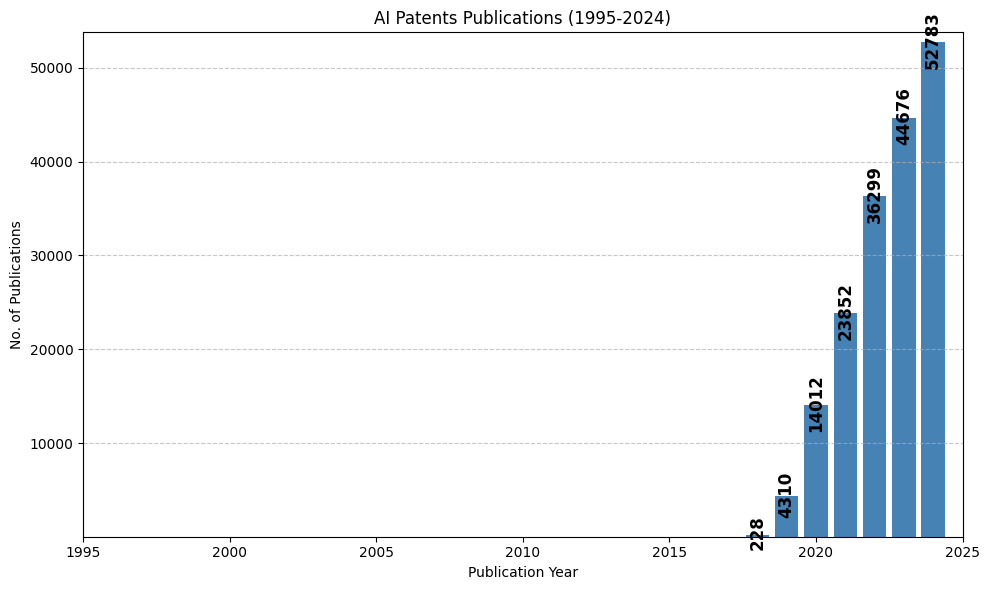

In [ ]:

# Count publications per year and compute cumulative sum
year_counts = df_all['Publication Year'].value_counts().sort_index()
#cumulative_counts = year_counts.cumsum()

# Plot cumulative bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(year_counts.index, year_counts.values, color='steelblue')

# Add values inside each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height+200 ,                   # Position inside bar
        str(height),                   # Label text
        ha='center', va='center',       # Center align
        color='black', fontsize=12, fontweight='bold',
        rotation=90
    )

# Axis labels and formatting
plt.xlabel('Publication Year')
plt.ylabel('No. of Publications')
plt.title('AI Patents Publications (1995-2024)')
plt.xlim(1995, 2025)
plt.ylim(10, year_counts.max() + 1000)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
year_counts.to_csv('AI_years.csv',index='true')
year_counts


,count
Publication Year,
2018.0,228
2019.0,4310
2020.0,14012
2021.0,23852
2022.0,36299
2023.0,44676
2024.0,52783


In [ ]:
df.columns


Index(['Publication Number', 'Application Date', 'Publication Date',
       'Assignee/Applicant', 'Claims Count', 'Assignee Count',
       'Inventor Count', 'Publication Country Code',
       'Count of Cited Refs - Patent', 'Count of Cited Refs - Non-patent',
       'Count of Citing Patents', 'DWPI Count of Family Members',
       'DWPI Count of Family Countries/Regions', 'Related Applications',
       'IPC - Current', 'CPC - Current', 'Priority Number', 'Priority Date',
       'Priority Date - DWPI', 'DWPI Family Members',
       'DWPI Family Members Dead/Alive', 'Dead/Alive', 'Opposition (EP)',
       'License (EP)', 'Strategic Importance', 'Probability of Grant',
       'Combined Patent Impact', 'Assignee - Original - Country/Region',
       'Application Number', 'Priority Year(s)', 'Application Year',
       'Publication Year', 'Application Month', 'Publication Month',
       'Citing Patents', 'Citing Pat 1st Assignee', 'Cited Refs - Patent',
       'Cited Pat 1st Assignee', 'Cited

In [ ]:
df=df[['Application Number','IPC - Current','Assignee/Applicant','Claims Count','Assignee Count','Inventor','Publication Country Code','Application Country/Region','Related Applications','Count of Cited Refs - Patent','Count of Cited Refs - Non-patent','Count of Citing Patents','DWPI Family Members','DWPI Count of Family Members','DWPI Count of Family Countries/Regions']]

In [ ]:
df_unseen=df_unseen[['Application Number','Publication Year','Application Year','IPC - Current','Assignee/Applicant','Claims Count','Assignee Count','Inventor','Publication Country Code','Application Country/Region','Related Applications','Count of Cited Refs - Patent','Count of Cited Refs - Non-patent','Count of Citing Patents','DWPI Family Members','DWPI Count of Family Members','DWPI Count of Family Countries/Regions']]

In [ ]:
df.shape
df_unseen.shape

(157653, 17)

In [ ]:
print('Total rows with nulls or blanks',len(df.columns[df.isna().all()].tolist() ))
print('Total rows with nulls ',len(df.columns[df.isnull().all()].tolist() ))
na_list = df.columns[df.isna().any()].tolist()

Total rows with nulls or blanks 0
Total rows with nulls  0


In [ ]:
#Now delete all the columns for which all rows are having value null
df = df.dropna(axis=1, how='all')
print('data shape=',df.shape)

data shape= (18557, 15)


In [ ]:
print('Total rows with nulls or blanks',len(df_unseen.columns[df_unseen.isna().all()].tolist() ))
#print('Total rows with nulls ',len(df.columns[df_unseen.isnull().all()].tolist() ))
na_list = df_unseen.columns[df_unseen.isna().any()].tolist()

Total rows with nulls or blanks 0


In [ ]:
#Now delete all the columns for which all rows are having value null
df_unseen = df_unseen.dropna(axis=1, how='all')
print('data shape=',df_unseen.shape)

data shape= (157653, 17)


In [ ]:
df.isnull().sum()

,0
Application Number,0
IPC - Current,228
Assignee/Applicant,46
Claims Count,141
Assignee Count,0
Inventor,162
Publication Country Code,7
Application Country/Region,0
Related Applications,14528
Count of Cited Refs - Patent,0


In [ ]:
df_unseen.isnull().sum()

,0
Application Number,0
Publication Year,43
Application Year,0
IPC - Current,6031
Assignee/Applicant,3243
Claims Count,1769
Assignee Count,0
Inventor,6177
Publication Country Code,43
Application Country/Region,0


In [ ]:
df['inventor_list']=df['Inventor'].str.split('|')
# Replace NaN or None values with an empty list, then count elements
df['count_inventor'] = df['inventor_list'].apply(lambda x: len(x) if isinstance(x, list) else 0)
df

,Application Number,IPC - Current,Assignee/Applicant,Claims Count,Assignee Count,Inventor,Publication Country Code,Application Country/Region,Related Applications,Count of Cited Refs - Patent,Count of Cited Refs - Non-patent,Count of Citing Patents,DWPI Family Members,DWPI Count of Family Members,DWPI Count of Family Countries/Regions,inventor_list,count_inventor
0,US16193956A,H04L002906 | G06F002156 | G06N000304 | G06N000308,"ACCENTURE GLOBAL SOLUTIONS LIMITED,Dublin,IE",20.0,2,"Farhady, Nahid | Ben Salem, Malek",US,US,US16193956A | 2018-11-16,17,0,5,EP3654217A1 | US20200162483A1 | US10880328B2 |...,4.0,45.0,"[Farhady, Nahid , Ben Salem, Malek]",2
1,US15993366A,G06V003040 | H04L002906 | G06N002000,"Jumio Corporation,Palo Alto,CA,US",24.0,2,"Balogh, Attila | Hochrieser, Reinhard | Rogoja...",US,US,US15993366A | 2018-05-30,15,2,1,US20190372968A1 | WO2019231698A1 | WO201923169...,5.0,134.0,"[Balogh, Attila , Hochrieser, Reinhard , Rog...",3
2,US16371556A,G06N002000 | H04L001246 | H04L004524 | H04L001228,"Cisco Technology Inc.,San Jose,CA,US",20.0,2,"Kumaran, Vikram | Vasseur, Jean-Philippe | Mer...",US,US,US16371556A | 2019-04-01,15,1,1,US20200313979A1 | US10880186B2,2.0,1.0,"[Kumaran, Vikram , Vasseur, Jean-Philippe , ...",4
3,US16354446A,A61B000651 | G06F0016532 | G06T000700 | G06V00...,"DIGIBRAIN4 INC.,Lake Zurich,IL,US | Kusnoto Bu...",11.0,5,"Kusnoto, Budi | Kaboudan, Ahmed | Bourauel, Ch...",US,US,US62648284P | 2018-03-26 | US16354446A | 2019-...,14,0,1,WO2019178617A1 | US20190295710A1 | US10878954B2,3.0,134.0,"[Kusnoto, Budi , Kaboudan, Ahmed , Bourauel,...",4
4,US16601992A,G10L002551 | G06N000504 | G06N002000 | G10L002...,"AUDIO ANALYTIC LTD | Audio Analytic Ltd,Cambri...",19.0,2,"Mitchell, Christopher James | Krstulovic, Sach...",US,US,NaN,9,0,16,US10878840B1,1.0,1.0,"[Mitchell, Christopher James , Krstulovic, Sa...",7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18552,TR201820716A,G06Q005000,TURKCELL TEKNOLOJÄ° ARAÅTIRMA VE GELÄ°ÅTÄ°RM...,11.0,1,SAMET ALKENT,TR,TR,NaN,0,0,0,WO2020139301A1 | TR201820716A2,2.0,134.0,[SAMET ALKENT],1
18553,TR201820115A,G06Q003000,TURKCELL TEKNOLOJÄ° ARAÅTIRMA VE GELÄ°ÅTÄ°RM...,8.0,1,ÃAÄATAY GÃKÃEL | ÃAÄRI ARTUN | KORAY KUR...,TR,TR,NaN,0,0,0,TR201820115A2,1.0,1.0,"[ÃAÄATAY GÃKÃEL , ÃAÄRI ARTUN , KORAY ...",4
18554,TR201819648A,A63H000300 | G06F001518 | G06N000504,TURKCELL TEKNOLOJÄ° ARAÅTIRMA VE GELÄ°ÅTÄ°RM...,23.0,1,ARZU BEHÄ°YE TARIMCI,TR,TR,NaN,0,0,0,TR201819648A2,1.0,1.0,[ARZU BEHÄ°YE TARIMCI],1
18555,TR201815979A,G06F001700,"TÃRK TELEKOMÃNÄ°KASYON A.Å.,TR",1.0,1,NESÄ°M AÄIR,TR,TR,NaN,0,0,0,NaN,NaN,NaN,[NESÄ°M AÄIR],1


In [ ]:
df_unseen['inventor_list']=df_unseen['Inventor'].str.split('|')
# Replace NaN or None values with an empty list, then count elements
df_unseen['count_inventor'] = df_unseen['inventor_list'].apply(lambda x: len(x) if isinstance(x, list) else 0)
df_unseen

,Application Number,Publication Year,Application Year,IPC - Current,Assignee/Applicant,Claims Count,Assignee Count,Inventor,Publication Country Code,Application Country/Region,Related Applications,Count of Cited Refs - Patent,Count of Cited Refs - Non-patent,Count of Citing Patents,DWPI Family Members,DWPI Count of Family Members,DWPI Count of Family Countries/Regions,inventor_list,count_inventor
0,US16575368A,2021.0,2019,H05K000720 | G05B001302 | G05B001304,"BAIDU USA LLC,Sunnyvale,CA,US",16.0,2,"Shao, Shuai | Gao, Tianyi",US,US,US16575368A | 2019-09-18,10,0,0,US20210084797A1 | CN112533436A | US11212946B2 ...,4.0,2.0,"[Shao, Shuai , Gao, Tianyi]",2
1,US16518859A,2021.0,2019,H04W002802 | G06N002000 | H04L001246 | H04W002...,"DISH Wireless L.L.C.,Englewood,CO,US",18.0,2,"Sorond, Mariam | Emami, Amirali | Chenumolu, S...",US,US,US16518859A | 2019-07-22,1,3,1,WO2021015988A1 | US20210029576A1 | US11212696B...,8.0,136.0,"[Sorond, Mariam , Emami, Amirali , Chenumolu...",3
2,US16600112A,2021.0,2019,H04L00472416 | G06N002000,"Juniper Networks Inc.,Sunnyvale,CA,US",18.0,2,"K S, Nithyananda Vishnu | Sekar, Sasikumar | D...",US,US,US16600112A | 2019-10-11,22,13,1,EP3806396A1 | US20210112011A1 | CN112653570A |...,6.0,46.0,"[K S, Nithyananda Vishnu , Sekar, Sasikumar ,...",4
3,US17019187A,2021.0,2020,G06N002000,"Microsoft Technology Licensing LLC,Redmond,WA,US",20.0,2,"Tamir, Gal | Lemberg, Rachel | Mashiah, Zakie ...",US,US,NaN,20,1,7,US11212195B1 | WO2022055575A1 | EP4211556A1,3.0,136.0,"[Tamir, Gal , Lemberg, Rachel , Mashiah, Zak...",6
4,US16691548A,2021.0,2019,H04L001228 | G06N000308 | G06T000773 | G06V001...,"LG ELECTRONICS INC.,Seoul,KR",12.0,2,"Jeong, Jangkeun",US,US,US16691548A | 2019-11-21,11,0,0,KR2019094128A | US20200092124A1 | US11212132B2,3.0,2.0,"[Jeong, Jangkeun]",1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22378,TR2023880A,2024.0,2023,G06Q003002 | G06Q003006 | G06N002000 | G06F001620,D-MARKET ELEKTRONÄ°K HÄ°ZMETLER VE TÄ°CARET AN...,7.0,1,ERSAN ÃZTÃRK | ÃAÄLAR EKER | ERMAN CEYLAN,TR,TR,NaN,0,0,0,NaN,NaN,NaN,"[ERSAN ÃZTÃRK , ÃAÄLAR EKER , ERMAN CEYLAN]",3
22379,TR202347A,2024.0,2023,G06F002131 | G06F002132 | G06Q002040 | G06N002020,"FÄ°BABANKA ANONÄ°M ÅÄ°RKETÄ°,TR",NaN,1,ILGIN ÅAFAK | FATMANUR KARAÄ°BRAHÄ°M | TANSEL...,TR,TR,NaN,0,0,0,NaN,NaN,NaN,"[ILGIN ÅAFAK , FATMANUR KARAÄ°BRAHÄ°M , TAN...",5
22380,TR202221623A,2024.0,2022,G06Q003006 | G07D001134 | G07G000100 | G06N002000,"MÄ°GROS TÄ°CARET ANONÄ°M ÅÄ°RKETÄ°,TR",NaN,1,YÃCEL KAÃAR | BUSE MERT | Ä°LKNUR EMRE | BÄ°...,TR,TR,NaN,0,0,0,NaN,NaN,NaN,"[YÃCEL KAÃAR , BUSE MERT , Ä°LKNUR EMRE , ...",8
22381,TR202317827A,2024.0,2023,G06N002000 | G06F002100,BTS KURUMSAL BÄ°LÄ°ÅÄ°M TEKNOLOJÄ°LERÄ° ANONÄ...,NaN,1,KIYMET KAYA ÃNAL | AYTAÃ KARAMEÅEOÄLU | GÃ...,TR,TR,NaN,0,0,0,NaN,NaN,NaN,"[KIYMET KAYA ÃNAL , AYTAÃ KARAMEÅEOÄLU , ...",4


In [ ]:
df.isnull().sum()

,0
Application Number,0
IPC - Current,228
Assignee/Applicant,46
Claims Count,141
Assignee Count,0
Inventor,162
Publication Country Code,7
Application Country/Region,0
Related Applications,14528
Count of Cited Refs - Patent,0


In [ ]:
print('df.shape',df.shape)

df.shape (18557, 17)


In [ ]:
df_unseen.isnull().sum()

,0
Application Number,0
Publication Year,43
Application Year,0
IPC - Current,6031
Assignee/Applicant,3243
Claims Count,1769
Assignee Count,0
Inventor,6177
Publication Country Code,43
Application Country/Region,0


In [ ]:
print('df_unseen.shape',df_unseen.shape)

df_unseen.shape (157653, 19)


In [ ]:
#Now check if there any duplicates present
#duplicate_rows = len(df[df.duplicated()])
#print('Duplicate rows ', duplicate_rows)

In [ ]:
#Check percentage of nulls or blanks in columns
df.isnull().sum()*100/len(df)
print(df.isnull().sum()*100/len(df))

Application Number                         0.000000
IPC - Current                              1.228647
Assignee/Applicant                         0.247885
Claims Count                               0.759821
Assignee Count                             0.000000
Inventor                                   0.872986
Publication Country Code                   0.037722
Application Country/Region                 0.000000
Related Applications                      78.288516
Count of Cited Refs - Patent               0.000000
Count of Cited Refs - Non-patent           0.000000
Count of Citing Patents                    0.000000
DWPI Family Members                        0.183219
DWPI Count of Family Members               0.183219
DWPI Count of Family Countries/Regions     0.183219
inventor_list                              0.872986
count_inventor                             0.000000
dtype: float64


In [ ]:
#Check percentage of nulls or blanks in columns
df_unseen.isnull().sum()*100/len(df_unseen)
print(df_unseen.isnull().sum()*100/len(df_unseen))

Application Number                         0.000000
Publication Year                           0.027275
Application Year                           0.000000
IPC - Current                              3.825490
Assignee/Applicant                         2.057049
Claims Count                               1.122085
Assignee Count                             0.000000
Inventor                                   3.918099
Publication Country Code                   0.027275
Application Country/Region                 0.000000
Related Applications                      64.239184
Count of Cited Refs - Patent               0.000000
Count of Cited Refs - Non-patent           0.000000
Count of Citing Patents                    0.000000
DWPI Family Members                        1.262266
DWPI Count of Family Members               1.262266
DWPI Count of Family Countries/Regions     1.262266
inventor_list                              3.918099
count_inventor                             0.000000
dtype: float

In [ ]:
prev_rows=len(df)

In [ ]:
df= df[df['IPC - Current'].notna()]
df= df[df['Claims Count'].notna()]
df= df[df['Assignee/Applicant'].notna()]
df= df[df['Inventor'].notna()]
df= df[df['DWPI Count of Family Members'].notna()]
df= df[df['DWPI Count of Family Countries/Regions'].notna()]

In [ ]:
after_rows=len(df)
total_deleted=((prev_rows-after_rows)*100)/prev_rows
print("Total % of rows deleted:",round(total_deleted,2))
print(df.shape)

Total % of rows deleted: 2.6
(18074, 17)


In [ ]:
'''df['Application Date'] = pd.to_datetime(df['Application Date'])
df['Publication Date'] = pd.to_datetime(df['Publication Date'])
df['grant_lag_days'] = (df['Publication Date'] - df['Application Date']).dt.days'''

"df['Application Date'] = pd.to_datetime(df['Application Date'])\ndf['Publication Date'] = pd.to_datetime(df['Publication Date'])\ndf['grant_lag_days'] = (df['Publication Date'] - df['Application Date']).dt.days"

In [ ]:
prev_rows=len(df_unseen)

In [ ]:
df_unseen= df_unseen[df_unseen['IPC - Current'].notna()]
df_unseen= df_unseen[df_unseen['Claims Count'].notna()]
df_unseen= df_unseen[df_unseen['Inventor'].notna()]
df_unseen= df_unseen[df_unseen['DWPI Count of Family Members'].notna()]
df_unseen= df_unseen[df_unseen['DWPI Count of Family Countries/Regions'].notna()]
df_unseen= df_unseen[df_unseen['Assignee/Applicant'].notna()]
#df_unseen= df_unseen[df_unseen['Optimized Assignee'].notna()]
#df_unseen= df_unseen[df_unseen['Ultimate Parent'].notna()]
#df_unseen= df_unseen[df_unseen['Inventor'].notna()]
#df_unseen= df_unseen[df_unseen['Claims Count'].notna()]


In [ ]:
after_rows=len(df_unseen)
total_deleted=((prev_rows-after_rows)*100)/prev_rows
print("Total % of rows deleted:",round(total_deleted,2))
print(df_unseen.shape)

Total % of rows deleted: 8.61
(144082, 19)


In [ ]:
'''df_unseen['Application Date'] = pd.to_datetime(df_unseen['Application Date'])
df_unseen['Publication Date'] = pd.to_datetime(df_unseen['Publication Date'])
df_unseen['grant_lag_days'] = (df_unseen['Publication Date'] - df_unseen['Application Date']).dt.days'''

"df_unseen['Application Date'] = pd.to_datetime(df_unseen['Application Date'])\ndf_unseen['Publication Date'] = pd.to_datetime(df_unseen['Publication Date'])\ndf_unseen['grant_lag_days'] = (df_unseen['Publication Date'] - df_unseen['Application Date']).dt.days"

In [ ]:
# Check if there is any more na
(df.isnull().sum()*100)/len(df)

,0
Application Number,0.000000
IPC - Current,0.000000
Assignee/Applicant,0.000000
Claims Count,0.000000
Assignee Count,0.000000
Inventor,0.000000
Publication Country Code,0.000000
Application Country/Region,0.000000
Related Applications,78.128804
Count of Cited Refs - Patent,0.000000


In [ ]:
# Convert the column into counts (count non-NaN values separated by '|', and 0 for NaN)
df['RelatedApplicationCount'] = df['Related Applications'].apply(lambda x: len(str(x).split('|')) if pd.notna(x) else 0)

print(df)

      Application Number                                      IPC - Current  \
0            US16193956A  H04L002906 | G06F002156 | G06N000304 | G06N000308   
1            US15993366A               G06V003040 | H04L002906 | G06N002000   
2            US16371556A  G06N002000 | H04L001246 | H04L004524 | H04L001228   
3            US16354446A  A61B000651 | G06F0016532 | G06T000700 | G06V00...   
4            US16601992A  G10L002551 | G06N000504 | G06N002000 | G10L002...   
...                  ...                                                ...   
18547       TR201911274A                                         G06Q001010   
18551         TR2019696A                                         G06Q001000   
18552       TR201820716A                                         G06Q005000   
18553       TR201820115A                                         G06Q003000   
18554       TR201819648A               A63H000300 | G06F001518 | G06N000504   

                                      Assignee/Appl

In [ ]:
df_unseen['RelatedApplicationCount'] = df_unseen['Related Applications'].apply(lambda x: len(str(x).split('|')) if pd.notna(x) else 0)

print(df_unseen)

      Application Number  Publication Year  Application Year  \
0            US16575368A            2021.0              2019   
1            US16518859A            2021.0              2019   
2            US16600112A            2021.0              2019   
3            US17019187A            2021.0              2020   
4            US16691548A            2021.0              2019   
...                  ...               ...               ...   
22318     SA12022430733A            2024.0              2022   
22319     SA52022441058A            2024.0              2022   
22320     SA52022440842A            2024.0              2022   
22321     SA52022433180A            2024.0              2022   
22322     SA52023440553A            2024.0              2023   

                                           IPC - Current  \
0                   H05K000720 | G05B001302 | G05B001304   
1      H04W002802 | G06N002000 | H04L001246 | H04W002...   
2                              H04L00472416 | G06N0

In [ ]:

# Create a new column for IPC Subclasses (split the IPCs and remove duplicates)
df['IPC Subclass'] = df['IPC - Current'].apply(lambda x: sorted(set(str(x).split('|'))) if pd.notna(x) and x != '' else [])

# Create a new column for IPC Subclass Counts (count the occurrences of each IPC subclass)
df['IPC Subclass Count'] = df['IPC - Current'].apply(lambda x: {subclass: str(x).split('|').count(subclass) for subclass in set(str(x).split('|'))} if pd.notna(x) and x != '' else {})

print(df)


      Application Number                                      IPC - Current  \
0            US16193956A  H04L002906 | G06F002156 | G06N000304 | G06N000308   
1            US15993366A               G06V003040 | H04L002906 | G06N002000   
2            US16371556A  G06N002000 | H04L001246 | H04L004524 | H04L001228   
3            US16354446A  A61B000651 | G06F0016532 | G06T000700 | G06V00...   
4            US16601992A  G10L002551 | G06N000504 | G06N002000 | G10L002...   
...                  ...                                                ...   
18547       TR201911274A                                         G06Q001010   
18551         TR2019696A                                         G06Q001000   
18552       TR201820716A                                         G06Q005000   
18553       TR201820115A                                         G06Q003000   
18554       TR201819648A               A63H000300 | G06F001518 | G06N000504   

                                      Assignee/Appl

In [ ]:
# Create a new column for IPC Subclasses (split the IPCs and remove duplicates)
df_unseen['IPC Subclass'] = df_unseen['IPC - Current'].apply(lambda x: sorted(set(str(x).split('|'))) if pd.notna(x) and x != '' else [])

# Create a new column for IPC Subclass Counts (count the occurrences of each IPC subclass)
df_unseen['IPC Subclass Count'] = df_unseen['IPC - Current'].apply(lambda x: {subclass: str(x).split('|').count(subclass) for subclass in set(str(x).split('|'))} if pd.notna(x) and x != '' else {})

print(df_unseen)

      Application Number  Publication Year  Application Year  \
0            US16575368A            2021.0              2019   
1            US16518859A            2021.0              2019   
2            US16600112A            2021.0              2019   
3            US17019187A            2021.0              2020   
4            US16691548A            2021.0              2019   
...                  ...               ...               ...   
22318     SA12022430733A            2024.0              2022   
22319     SA52022441058A            2024.0              2022   
22320     SA52022440842A            2024.0              2022   
22321     SA52022433180A            2024.0              2022   
22322     SA52023440553A            2024.0              2023   

                                           IPC - Current  \
0                   H05K000720 | G05B001302 | G05B001304   
1      H04W002802 | G06N002000 | H04L001246 | H04W002...   
2                              H04L00472416 | G06N0

In [ ]:
# Convert the column into counts (count the number of values separated by '|', 0 for NaN or empty strings)
df['IPC - Current Count'] = df['IPC - Current'].apply(lambda x: len(str(x).split('|')) if pd.notna(x) and x != '' else 0)

print(df)

      Application Number                                      IPC - Current  \
0            US16193956A  H04L002906 | G06F002156 | G06N000304 | G06N000308   
1            US15993366A               G06V003040 | H04L002906 | G06N002000   
2            US16371556A  G06N002000 | H04L001246 | H04L004524 | H04L001228   
3            US16354446A  A61B000651 | G06F0016532 | G06T000700 | G06V00...   
4            US16601992A  G10L002551 | G06N000504 | G06N002000 | G10L002...   
...                  ...                                                ...   
18547       TR201911274A                                         G06Q001010   
18551         TR2019696A                                         G06Q001000   
18552       TR201820716A                                         G06Q005000   
18553       TR201820115A                                         G06Q003000   
18554       TR201819648A               A63H000300 | G06F001518 | G06N000504   

                                      Assignee/Appl

In [ ]:
# Convert the column into counts (count the number of values separated by '|', 0 for NaN or empty strings)
df_unseen['IPC - Current Count'] = df_unseen['IPC - Current'].apply(lambda x: len(str(x).split('|')) if pd.notna(x) and x != '' else 0)

print(df_unseen)

      Application Number  Publication Year  Application Year  \
0            US16575368A            2021.0              2019   
1            US16518859A            2021.0              2019   
2            US16600112A            2021.0              2019   
3            US17019187A            2021.0              2020   
4            US16691548A            2021.0              2019   
...                  ...               ...               ...   
22318     SA12022430733A            2024.0              2022   
22319     SA52022441058A            2024.0              2022   
22320     SA52022440842A            2024.0              2022   
22321     SA52022433180A            2024.0              2022   
22322     SA52023440553A            2024.0              2023   

                                           IPC - Current  \
0                   H05K000720 | G05B001302 | G05B001304   
1      H04W002802 | G06N002000 | H04L001246 | H04W002...   
2                              H04L00472416 | G06N0

In [ ]:
# Extract the 4-digit IPC Subclass (first 4 characters)
df['IPC Subclass 4-digit'] = df['IPC - Current'].apply(lambda x: sorted(set([subclass[:4] for subclass in str(x).split('|')])) if pd.notna(x) and x != '' else [])

# Create a column for the counts of each 4-digit IPC Subclass
df['IPC Subclass Count'] = df['IPC - Current'].apply(
    lambda x: {subclass[:4]: [subclass[:4] for subclass in str(x).split('|')].count(subclass[:4])
               for subclass in set([subclass[:4] for subclass in str(x).split('|')])}
    if pd.notna(x) and x != '' else {}
)

# Count the number of subclasses in each row
df['Sub Class Count'] = df['IPC Subclass 4-digit'].apply(lambda x: len(x))

print(df)
df['IPC Subclass 4-digit'].value_counts()
print(df)

      Application Number                                      IPC - Current  \
0            US16193956A  H04L002906 | G06F002156 | G06N000304 | G06N000308   
1            US15993366A               G06V003040 | H04L002906 | G06N002000   
2            US16371556A  G06N002000 | H04L001246 | H04L004524 | H04L001228   
3            US16354446A  A61B000651 | G06F0016532 | G06T000700 | G06V00...   
4            US16601992A  G10L002551 | G06N000504 | G06N002000 | G10L002...   
...                  ...                                                ...   
18547       TR201911274A                                         G06Q001010   
18551         TR2019696A                                         G06Q001000   
18552       TR201820716A                                         G06Q005000   
18553       TR201820115A                                         G06Q003000   
18554       TR201819648A               A63H000300 | G06F001518 | G06N000504   

                                      Assignee/Appl

In [ ]:
# Extract the 4-digit IPC Subclass (first 4 characters)
df_unseen['IPC Subclass 4-digit'] = df_unseen['IPC - Current'].apply(lambda x: sorted(set([subclass[:4] for subclass in str(x).split('|')])) if pd.notna(x) and x != '' else [])

# Create a column for the counts of each 4-digit IPC Subclass
df_unseen['IPC Subclass Count'] = df_unseen['IPC - Current'].apply(
    lambda x: {subclass[:4]: [subclass[:4] for subclass in str(x).split('|')].count(subclass[:4])
               for subclass in set([subclass[:4] for subclass in str(x).split('|')])}
    if pd.notna(x) and x != '' else {}
)

# Count the number of subclasses in each row
df_unseen['Sub Class Count'] = df_unseen['IPC Subclass 4-digit'].apply(lambda x: len(x))

print(df_unseen)
df_unseen['IPC Subclass 4-digit'].value_counts()
print(df_unseen)

      Application Number  Publication Year  Application Year  \
0            US16575368A            2021.0              2019   
1            US16518859A            2021.0              2019   
2            US16600112A            2021.0              2019   
3            US17019187A            2021.0              2020   
4            US16691548A            2021.0              2019   
...                  ...               ...               ...   
22318     SA12022430733A            2024.0              2022   
22319     SA52022441058A            2024.0              2022   
22320     SA52022440842A            2024.0              2022   
22321     SA52022433180A            2024.0              2022   
22322     SA52023440553A            2024.0              2023   

                                           IPC - Current  \
0                   H05K000720 | G05B001302 | G05B001304   
1      H04W002802 | G06N002000 | H04L001246 | H04W002...   
2                              H04L00472416 | G06N0

In [ ]:
# Check if there is any more na
(df.isnull().sum()*100)/len(df)

,0
Application Number,0.000000
IPC - Current,0.000000
Assignee/Applicant,0.000000
Claims Count,0.000000
Assignee Count,0.000000
Inventor,0.000000
Publication Country Code,0.000000
Application Country/Region,0.000000
Related Applications,78.128804
Count of Cited Refs - Patent,0.000000


In [ ]:
#df.nunique().sort_values()
# Check if there is any more na
(df_unseen.isnull().sum()*100)/len(df_unseen)

,0
Application Number,0.000000
Publication Year,0.000000
Application Year,0.000000
IPC - Current,0.000000
Assignee/Applicant,0.000000
Claims Count,0.000000
Assignee Count,0.000000
Inventor,0.000000
Publication Country Code,0.000000
Application Country/Region,0.000000


In [ ]:
Field_list_sort=['Claims Count','Assignee Count','count_inventor','Count of Cited Refs - Patent','Count of Cited Refs - Non-patent','Count of Citing Patents','DWPI Count of Family Members','DWPI Count of Family Countries/Regions','IPC - Current Count','RelatedApplicationCount']
df['High Quality'] = 0  # Initialize all rows with 0
for i in Field_list_sort:
# Step 1: Sort the DataFrame based on 'Claims Count' in descending order
 df = df.sort_values(by=i, ascending=False).reset_index(drop=True)

# Step 2: Calculate the number of rows representing the top 5%
 top_5_percent_index = int(len(df) * 0.05)

# Step 3: Set 'High Quality' to 0 for all rows and 1 for the top 5%
 df.loc[:top_5_percent_index, 'High Quality'] = 1




print(df)


      Application Number                          IPC - Current  \
0            US16796289A   G05D000100 | G05D000102 | G06N002000   
1            US16796744A   G05D000100 | G05D000102 | G06N002000   
2            US16796785A   G05D000100 | G05D000102 | G06N002000   
3            US16796794A   G05D000100 | G05D000102 | G06N002000   
4            US16796264A   G05D000100 | G05D000102 | G06N002000   
...                  ...                                    ...   
18069    CN201910317985A   G01N002904 | G06F001718 | G06N002000   
18070      WO2019KR5731A  G08B002104 | G06N000308 | H04M0001725   
18071      WO2019KR8872A  G06N000308 | G06N000304 | G06V0010776   
18072        US16433484A  G06N000304 | G06N000308 | G06V0010764   
18073        US16716160A   G08G000500 | G06N000308 | G06N002000   

                                      Assignee/Applicant  Claims Count  \
0                           KACHE.AI,San Francisco,CA,US          20.0   
1                           KACHE.AI,San Franci

In [ ]:
df.head()

,Application Number,IPC - Current,Assignee/Applicant,Claims Count,Assignee Count,Inventor,Publication Country Code,Application Country/Region,Related Applications,Count of Cited Refs - Patent,Count of Cited Refs - Non-patent,Count of Citing Patents,DWPI Family Members,DWPI Count of Family Members,DWPI Count of Family Countries/Regions,inventor_list,count_inventor,RelatedApplicationCount,IPC Subclass,IPC Subclass Count,IPC - Current Count,IPC Subclass 4-digit,Sub Class Count,High Quality
0,US16796289A,G05D000100 | G05D000102 | G06N002000,"KACHE.AI,San Francisco,CA,US",20.0,1,"Riggs, Eli | Culkin, Catherine",US,US,US62697915P | 2018-07-13 | US62697919P | 2018-...,51,2,6,US20200192374A1 | US11573569B2,2.0,1.0,"[Riggs, Eli , Culkin, Catherine]",2,34,"[ G05D000102 , G06N002000, G05D000100 ]","{' G06': 1, 'G05D': 1, ' G05': 1}",3,"[ G05, G06, G05D]",3,1
1,US16796744A,G05D000100 | G05D000102 | G06N002000,"KACHE.AI,San Francisco,CA,US",20.0,1,"Levandowski, Anthony | Schwarte, Bernward | Ar...",US,US,US62697915P | 2018-07-13 | US62697919P | 2018-...,53,2,6,US20200192377A1 | US12093039B2,2.0,1.0,"[Levandowski, Anthony , Schwarte, Bernward , ...",3,34,"[ G05D000102 , G06N002000, G05D000100 ]","{' G06': 1, 'G05D': 1, ' G05': 1}",3,"[ G05, G06, G05D]",3,1
2,US16796785A,G05D000100 | G05D000102 | G06N002000,"KACHE.AI,San Francisco,CA,US",20.0,1,"Bernstein, David",US,US,US62697915P | 2018-07-13 | US62697919P | 2018-...,59,2,6,US20200192380A1 | US12093040B2,2.0,1.0,"[Bernstein, David]",1,34,"[ G05D000102 , G06N002000, G05D000100 ]","{' G06': 1, 'G05D': 1, ' G05': 1}",3,"[ G05, G06, G05D]",3,1
3,US16796794A,G05D000100 | G05D000102 | G06N002000,"KACHE.AI,San Francisco,CA,US",20.0,1,"Levandowski, Anthony | Riggs, Eli",US,US,US62697915P | 2018-07-13 | US62697919P | 2018-...,44,0,10,US20200192381A1,1.0,1.0,"[Levandowski, Anthony , Riggs, Eli]",2,34,"[ G05D000102 , G06N002000, G05D000100 ]","{' G06': 1, 'G05D': 1, ' G05': 1}",3,"[ G05, G06, G05D]",3,1
4,US16796264A,G05D000100 | G05D000102 | G06N002000,"KACHE.AI,San Francisco,CA,US",20.0,1,"Levandowski, Anthony | Riggs, Eli | Culkin, Ca...",US,US,US62697915P | 2018-07-13 | US62697919P | 2018-...,50,2,7,US20200192373A1 | US11422556B2,2.0,1.0,"[Levandowski, Anthony , Riggs, Eli , Culkin,...",3,34,"[ G05D000102 , G06N002000, G05D000100 ]","{' G06': 1, 'G05D': 1, ' G05': 1}",3,"[ G05, G06, G05D]",3,1


In [ ]:
df.to_csv('AIPreprocessed2020.csv', index=False) #after sort operation on numerical fields

In [ ]:
#droping non numeric values IPC - Current Count
#df.drop(['Application Number','Front Page Drawing', 'Front Page Image'],axis=1, inplace=True)
feature_names=['Claims Count','Assignee Count','count_inventor','Count of Cited Refs - Patent','Count of Cited Refs - Non-patent',
       'Count of Citing Patents','DWPI Count of Family Members','DWPI Count of Family Countries/Regions','RelatedApplicationCount',
        'IPC - Current Count','Sub Class Count','High Quality']#
training_features = df[feature_names]

#df=df[]

#Now delete all the columns for which all rows are having value null
df[feature_names] = df[feature_names].dropna(axis=1, how='all')
print('data shape=',df[feature_names].shape)
# Check if there is any more na
(df.isnull().sum()*100)/len(df)

data shape= (18074, 12)


,0
Application Number,0.000000
IPC - Current,0.000000
Assignee/Applicant,0.000000
Claims Count,0.000000
Assignee Count,0.000000
Inventor,0.000000
Publication Country Code,0.000000
Application Country/Region,0.000000
Related Applications,78.128804
Count of Cited Refs - Patent,0.000000


In [ ]:
df[feature_names].head()

,Claims Count,Assignee Count,count_inventor,Count of Cited Refs - Patent,Count of Cited Refs - Non-patent,Count of Citing Patents,DWPI Count of Family Members,DWPI Count of Family Countries/Regions,RelatedApplicationCount,IPC - Current Count,Sub Class Count,High Quality
0,20.0,1,2,51,2,6,2.0,1.0,34,3,3,1
1,20.0,1,3,53,2,6,2.0,1.0,34,3,3,1
2,20.0,1,1,59,2,6,2.0,1.0,34,3,3,1
3,20.0,1,2,44,0,10,1.0,1.0,34,3,3,1
4,20.0,1,3,50,2,7,2.0,1.0,34,3,3,1


In [ ]:
#df[feature_names].to_csv('AIPreprocessed_numbers1820.csv', index=False) #for assesment file
df_num=df[feature_names]

In [ ]:
X=df[['Claims Count','Assignee Count','count_inventor','Count of Cited Refs - Patent','Count of Cited Refs - Non-patent',
       'Count of Citing Patents','DWPI Count of Family Members','DWPI Count of Family Countries/Regions','RelatedApplicationCount',
        'IPC - Current Count','Sub Class Count']]#
y=df['High Quality']
#X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)
#X_test

In [ ]:
# Train test split - 80% training data, 20% validation data
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.20, random_state=100)

In [ ]:
# Checking the shape after split
print('X_train Shape:', X_train.shape)
print('y_train Shape:', y_train.shape)
print('X_val Shape:', X_val.shape)
print('y_val Shape:', y_val.shape)

X_train Shape: (14459, 11)
y_train Shape: (14459,)
X_val Shape: (3615, 11)
y_val Shape: (3615,)


In [ ]:
#smt = SMOTE(random_state=2)
#X_train_smote, y_train_smote = smt.fit_resample(X_train, y_train)

In [ ]:
pca = PCA()
pca_components = pca.fit_transform(X_train)
pca_components

array([[-4.83126361e+01, -2.80565120e+00,  7.16660931e+00, ...,
         1.83399683e+00, -2.38706494e-01,  1.74430608e-01],
       [ 8.54135808e+01, -1.06943131e+01, -7.16322313e+00, ...,
        -6.55676750e-01, -1.75352980e-01, -1.08123829e-01],
       [-4.60304100e+01, -5.58103450e+00,  5.86330798e+00, ...,
         4.73050655e-01,  7.01401093e-01, -6.44609762e-01],
       ...,
       [-4.95373139e+01, -2.90423986e+00, -3.38950282e+00, ...,
        -5.87259532e-01,  6.11546017e-01,  5.94311510e-01],
       [ 8.40408743e+01, -6.84843697e+00, -9.54396476e+00, ...,
        -1.92502367e+00, -2.45618471e-01,  8.00049086e-02],
       [ 8.54931817e+01, -6.72871807e+00,  4.16000419e+00, ...,
        -4.28418698e-01, -2.12398448e-01, -1.42608852e-01]])

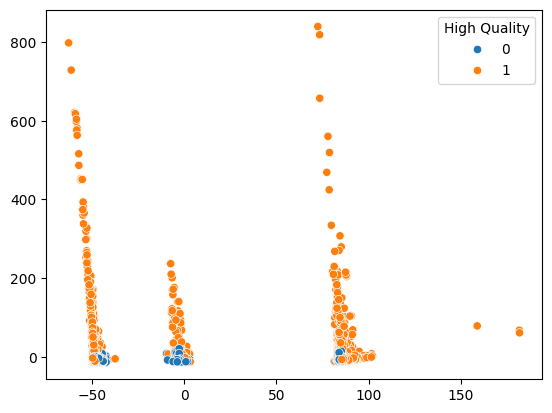

In [ ]:
sns.scatterplot(x=pca_components[:,0], y=pca_components[:,1], hue=y_train)
plt.show()

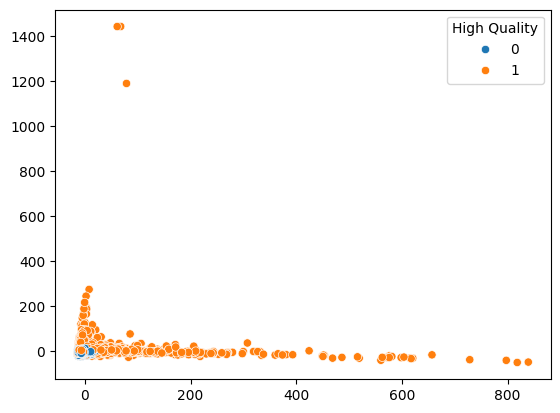

In [ ]:
sns.scatterplot(x=pca_components[:,1], y=pca_components[:,2], hue=y_train)
plt.show()

In [ ]:
def outlier_handling(dataframe):
    """
    Applies outlier handling transformations to the values in the given DataFrame.

    Parameters:
    - dataframe (DataFrame): The DataFrame containing the values to be transformed.

    Returns:
    - transformed_values (list): A list containing the transformed values based on the specified conditions.
    """

    transformed_values = []
    for value in dataframe:
        if value <= 0:
            transformed_values.append(float(0))
        elif float(value) == float(1.0):
            transformed_values.append(float(1.5))
        else:
            transformed_values.append(float(np.log1p(value)))

    return transformed_values


In [ ]:
def calculate_classification_metrics(y_true, y_pred):
    """
    Calculate various classification metrics.

    Parameters:
    y_true (array-like): True labels.
    y_pred (array-like): Predicted labels.

    Returns:
    pd.DataFrame: A DataFrame containing the calculated metrics.
    """
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    print('Confusion Matrix')
    print()
    print(cm)

    # True Positives, False Positives, True Negatives, False Negatives
    TP = cm[1, 1]
    FP = cm[0, 1]
    TN = cm[0, 0]
    FN = cm[1, 0]

    # Accuracy Score
    accuracy = round((TP + TN) / (TP + FP + TN + FN), 4)

    # Sensitivity (Recall or True Positive Rate)
    sensitivity = round(TP / (TP + FN), 4)

    # Specificity
    specificity = round(TN / (TN + FP), 4)

    # Precision
    precision = round(TP / (TP + FP), 4)

    # False Positive Rate
    false_positive_rate = round(FP / (FP + TN), 4)

    # True Positive Rate
    true_positive_rate = sensitivity

    metrics_df = pd.DataFrame({
        'Metric': ['Accuracy', 'Sensitivity', 'Specificity', 'Precision', 'False Positive Rate', 'True Positive Rate'],
        'Value': [accuracy, sensitivity, specificity, precision, false_positive_rate, true_positive_rate]
    })

    return metrics_df

In [ ]:
def draw_roc(actual, probs):
    fpr, tpr, thresholds = roc_curve(actual, probs,drop_intermediate = False)
    auc_score = roc_auc_score( actual, probs )
    plt.figure(figsize=(6, 6))
    plt.plot( fpr, tpr, label='ROC curve (area = %0.2f)' % auc_score)
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate or [1 - True Negative Rate]')
    plt.ylabel('True Positive Rate')
    plt.title('ROC AUC Curve')
    plt.legend(loc="lower right")
    plt.show()

    return fpr, tpr, thresholds

In [ ]:
rf = RandomForestClassifier(random_state=42)

In [ ]:
param_grid = {
    'n_estimators': [100],
    'max_depth': [5, 10],
    'min_samples_split': [2, 5, 10],
}

In [ ]:
rf_grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

In [ ]:
%%time
# Re-initialize the RandomForestClassifier and GridSearchCV to ensure correct parameter loading
rf = RandomForestClassifier(random_state=42)
rf_grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

# Fit the grid search to the training data
rf_grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
CPU times: user 918 ms, sys: 28.9 ms, total: 947 ms
Wall time: 15.1 s


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10], 'min_samples_split': [2, 5, 10],
                         'n_estimators': [100]},
             scoring='accuracy', verbose=1)

In [ ]:
# Get the best parameters
best_params = rf_grid_search.best_params_
print("Best Parameters:", best_params)

# Get the best model
best_model = rf_grid_search.best_estimator_

# Predict on train set using the best model
y_train_pred = rf_grid_search.predict(X_train)

# Predict on train set using the validation model
y_val_pred = rf_grid_search.predict(X_val)

Best Parameters: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 100}


In [ ]:
## Metrics on the train set
calculate_classification_metrics(y_train, y_train_pred)

Confusion Matrix

[[9398  122]
 [ 374 4565]]


,Metric,Value
0,Accuracy,0.9657
1,Sensitivity,0.9243
2,Specificity,0.9872
3,Precision,0.9740
4,False Positive Rate,0.0128
5,True Positive Rate,0.9243


In [ ]:
# Metrics on the validation set
calculate_classification_metrics(y_val, y_val_pred)

Confusion Matrix

[[2317   49]
 [ 109 1140]]


,Metric,Value
0,Accuracy,0.9563
1,Sensitivity,0.9127
2,Specificity,0.9793
3,Precision,0.9588
4,False Positive Rate,0.0207
5,True Positive Rate,0.9127


In [ ]:
# Generate a classification report
class_report = classification_report(y_val, y_val_pred)
print("Classification Report:\n", class_report)

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.98      0.97      2366
           1       0.96      0.91      0.94      1249

    accuracy                           0.96      3615
   macro avg       0.96      0.95      0.95      3615
weighted avg       0.96      0.96      0.96      3615



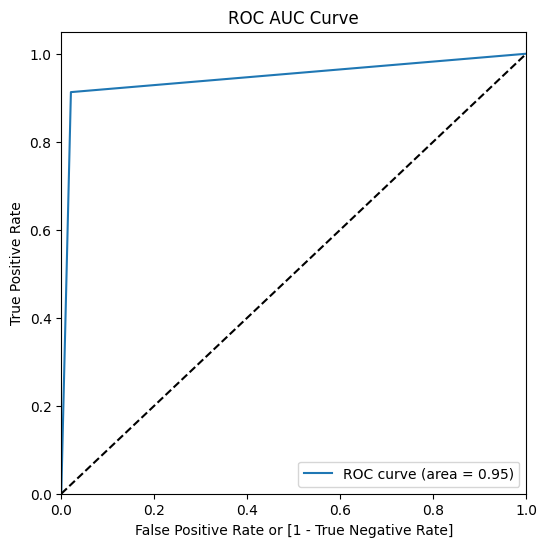

In [ ]:
from sklearn.metrics import roc_curve
# ROC curve
fpr, tpr, thresholds = draw_roc(y_val, y_val_pred)

In [ ]:
#out file prepration
#Read AI patent data and convert into data frame
#df_unseen=pd.read_csv("AI_csv2123.csv",skiprows=1)
df_unseen

,Application Number,Publication Year,Application Year,IPC - Current,Assignee/Applicant,Claims Count,Assignee Count,Inventor,Publication Country Code,Application Country/Region,Related Applications,Count of Cited Refs - Patent,Count of Cited Refs - Non-patent,Count of Citing Patents,DWPI Family Members,DWPI Count of Family Members,DWPI Count of Family Countries/Regions,inventor_list,count_inventor,RelatedApplicationCount,IPC Subclass,IPC Subclass Count,IPC - Current Count,IPC Subclass 4-digit,Sub Class Count
0,US16575368A,2021.0,2019,H05K000720 | G05B001302 | G05B001304,"BAIDU USA LLC,Sunnyvale,CA,US",16.0,2,"Shao, Shuai | Gao, Tianyi",US,US,US16575368A | 2019-09-18,10,0,0,US20210084797A1 | CN112533436A | US11212946B2 ...,4.0,2.0,"[Shao, Shuai , Gao, Tianyi]",2,2,"[ G05B001302 , G05B001304, H05K000720 ]","{' G05': 2, 'H05K': 1}",3,"[ G05, H05K]",2
1,US16518859A,2021.0,2019,H04W002802 | G06N002000 | H04L001246 | H04W002...,"DISH Wireless L.L.C.,Englewood,CO,US",18.0,2,"Sorond, Mariam | Emami, Amirali | Chenumolu, S...",US,US,US16518859A | 2019-07-22,1,3,1,WO2021015988A1 | US20210029576A1 | US11212696B...,8.0,136.0,"[Sorond, Mariam , Emami, Amirali , Chenumolu...",3,2,"[ G06N002000 , H04L001246 , H04W002408 , H0...","{'H04W': 1, ' H04': 3, ' G06': 1}",5,"[ G06, H04, H04W]",3
2,US16600112A,2021.0,2019,H04L00472416 | G06N002000,"Juniper Networks Inc.,Sunnyvale,CA,US",18.0,2,"K S, Nithyananda Vishnu | Sekar, Sasikumar | D...",US,US,US16600112A | 2019-10-11,22,13,1,EP3806396A1 | US20210112011A1 | CN112653570A |...,6.0,46.0,"[K S, Nithyananda Vishnu , Sekar, Sasikumar ,...",4,2,"[ G06N002000, H04L00472416 ]","{'H04L': 1, ' G06': 1}",2,"[ G06, H04L]",2
3,US17019187A,2021.0,2020,G06N002000,"Microsoft Technology Licensing LLC,Redmond,WA,US",20.0,2,"Tamir, Gal | Lemberg, Rachel | Mashiah, Zakie ...",US,US,NaN,20,1,7,US11212195B1 | WO2022055575A1 | EP4211556A1,3.0,136.0,"[Tamir, Gal , Lemberg, Rachel , Mashiah, Zak...",6,0,[G06N002000],{'G06N': 1},1,[G06N],1
4,US16691548A,2021.0,2019,H04L001228 | G06N000308 | G06T000773 | G06V001...,"LG ELECTRONICS INC.,Seoul,KR",12.0,2,"Jeong, Jangkeun",US,US,US16691548A | 2019-11-21,11,0,0,KR2019094128A | US20200092124A1 | US11212132B2,3.0,2.0,"[Jeong, Jangkeun]",1,2,"[ G06N000308 , G06T000773 , G06V0010764 , H...","{'H04L': 1, ' H04': 2, ' G06': 3}",6,"[ G06, H04, H04L]",3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22318,SA12022430733A,2024.0,2022,H02J000100 | G06N002000,"AIR PRODUCTS AND CHEMICALS INC.,US | Ø§ÙØ± Ø¨...",20.0,1,Sanjay Mehta | PRATIK MISRA | Ø³Ø§ÙØ¬Ø§Ù Ù Ù...,SA,SA,NaN,0,0,0,CA3150613A1 | AU2022201356A1 | CN115034424A | ...,15.0,52.0,"[Sanjay Mehta , PRATIK MISRA , Ø³Ø§ÙØ¬Ø§Ù ...",4,0,"[ G06N002000, H02J000100 ]","{'H02J': 1, ' G06': 1}",2,"[ G06, H02J]",2
22319,SA52022441058A,2024.0,2022,G06N000308 | G06T000700,"SAUDI ARABIAN OIL COMPANY,SA | Ø´Ø±ÙÙÙÙÙØ...",18.0,1,Kamil Rahman Muhammad Shelby | Ahmad ALDABBAGH...,SA,SA,NaN,0,0,0,WO2021222422A1 | US20210340857A1 | US11377945B...,5.0,135.0,"[Kamil Rahman Muhammad Shelby , Ahmad ALDABBA...",4,0,"[ G06T000700, G06N000308 ]","{'G06N': 1, ' G06': 1}",2,"[ G06, G06N]",2
22320,SA52022440842A,2024.0,2022,E21B004100,"SAUDI ARABIAN OIL COMPANY,SA | Ø´Ø±ÙØ© Ø§ÙØ²...",15.0,1,"AQEEL, Nauman | KHAN, Waqas Ahmed | HASAN, Sua...",SA,SA,NaN,0,0,0,US20210310345A1 | WO2021207151A1 | SA520224408...,5.0,135.0,"[AQEEL, Nauman , KHAN, Waqas Ahmed , HASAN, ...",8,0,[E21B004100],{'E21B': 1},1,[E21B],1
22321,SA52022433180A,2024.0,2022,E21B004702 | E21B0047085 | E21B004100,"Halliburton Energy Services Inc.,US | ÙØ§ÙÙ...",20.0,1,"FOUDA, Ahmed Elsayed | GUNER, Baris | Ø§Ø­Ù Ø¯...",SA,SA,NaN,0,0,0,US20210256671A1 | WO2021167634A1 | US11216926B...,6.0,135.0,"[FOUDA, Ahmed Elsayed , GUNER, Baris , Ø§Ø­Ù...",4,0,"[ E21B004100, E21B0047085 , E21B004702 ]","{' E21': 2, 'E21B': 1}",3,"[ E21, E21B]",2


In [ ]:
scaler = StandardScaler()
num_vars = ['Claims Count','Assignee Count','count_inventor','Count of Cited Refs - Patent','Count of Cited Refs - Non-patent',
       'Count of Citing Patents','DWPI Count of Family Members','DWPI Count of Family Countries/Regions','RelatedApplicationCount',
        'IPC - Current Count','Sub Class Count']#
df_unseen_scaled= scaler.fit_transform(df_unseen[num_vars])
df_unseen_scaled

array([[ 0.04289127,  0.59830045, -0.7756995 , ...,  0.32056607,
        -0.52474654, -0.40152841],
       [ 0.18808111,  0.59830045, -0.57673428, ...,  0.32056607,
         0.18275912,  0.86418036],
       [ 0.18808111,  0.59830045, -0.37776906, ...,  0.32056607,
        -0.87849938, -0.40152841],
       ...,
       [-0.02970365, -0.35548769,  0.41809182, ..., -0.60682532,
        -1.23225221, -1.66723719],
       [ 0.33327095, -0.35548769, -0.37776906, ..., -0.60682532,
        -0.52474654, -0.40152841],
       [-0.17489349, -0.35548769,  0.41809182, ..., -0.60682532,
        -0.52474654,  0.86418036]])

In [ ]:
num_vars = ['Claims Count','Assignee Count','count_inventor','Count of Cited Refs - Patent','Count of Cited Refs - Non-patent',
       'Count of Citing Patents','DWPI Count of Family Members','DWPI Count of Family Countries/Regions','RelatedApplicationCount',
        'IPC - Current Count','Sub Class Count']
#df_unseen[num_vars] = scaler.fit_transform(df_unseen[num_vars])
#df_unseen_num.head()
#df_unseen_num=df_unseen_num1
#df_unseen_num.dropna(how='all', inplace=True)
df_unseen = df_unseen.dropna(subset=['Claims Count','Assignee Count','count_inventor','Count of Cited Refs - Patent','Count of Cited Refs - Non-patent',
       'Count of Citing Patents','DWPI Count of Family Members','DWPI Count of Family Countries/Regions','RelatedApplicationCount',
        'IPC - Current Count','Sub Class Count'])
#df_unseen_num = df_unseen_num.dropna()
# Use SandardScaler to scale values
#scaler = StandardScaler()

# Fit and transform training set
X_unseen_scaled = pd.DataFrame(df_unseen_scaled, columns =df_unseen[num_vars].columns, index = df_unseen.index)
X_unseen_scaled

,Claims Count,Assignee Count,count_inventor,Count of Cited Refs - Patent,Count of Cited Refs - Non-patent,Count of Citing Patents,DWPI Count of Family Members,DWPI Count of Family Countries/Regions,RelatedApplicationCount,IPC - Current Count,Sub Class Count
0,0.042891,0.598300,-0.775699,0.066879,-0.200854,-0.304245,0.096782,-0.676646,0.320566,-0.524747,-0.401528
1,0.188081,0.598300,-0.576734,-0.197751,0.044393,-0.072819,0.829238,1.511824,0.320566,0.182759,0.864180
2,0.188081,0.598300,-0.377769,0.419719,0.861886,-0.072819,0.463010,0.041956,0.320566,-0.878499,-0.401528
3,0.333271,0.598300,0.020161,0.360912,-0.119105,1.315736,-0.086332,1.511824,-0.606825,-1.232252,-1.667237
4,-0.247488,0.598300,-0.974665,0.096282,-0.200854,-0.304245,-0.086332,-0.676646,0.320566,0.536512,0.864180
...,...,...,...,...,...,...,...,...,...,...,...
22318,0.333271,-0.355488,-0.377769,-0.227154,-0.200854,-0.304245,2.111037,0.139947,-0.606825,-0.878499,-0.401528
22319,0.188081,-0.355488,-0.377769,-0.227154,-0.200854,-0.304245,0.279896,1.495492,-0.606825,-0.878499,-0.401528
22320,-0.029704,-0.355488,0.418092,-0.227154,-0.200854,-0.304245,0.279896,1.495492,-0.606825,-1.232252,-1.667237
22321,0.333271,-0.355488,-0.377769,-0.227154,-0.200854,-0.304245,0.463010,1.495492,-0.606825,-0.524747,-0.401528


In [ ]:
df_unseen_scaled

array([[ 0.04289127,  0.59830045, -0.7756995 , ...,  0.32056607,
        -0.52474654, -0.40152841],
       [ 0.18808111,  0.59830045, -0.57673428, ...,  0.32056607,
         0.18275912,  0.86418036],
       [ 0.18808111,  0.59830045, -0.37776906, ...,  0.32056607,
        -0.87849938, -0.40152841],
       ...,
       [-0.02970365, -0.35548769,  0.41809182, ..., -0.60682532,
        -1.23225221, -1.66723719],
       [ 0.33327095, -0.35548769, -0.37776906, ..., -0.60682532,
        -0.52474654, -0.40152841],
       [-0.17489349, -0.35548769,  0.41809182, ..., -0.60682532,
        -0.52474654,  0.86418036]])

In [ ]:
# Store original scaled features for prediction
X_unseen_features = X_unseen_scaled.copy()

# Predict with Random Forest
df_unseen['High Quality_RF'] = rf_grid_search.predict(X_unseen_features)
df_unseen.to_csv('AIOutputRF.csv',index=True)

In [ ]:
df_unseen.columns

Index(['Application Number', 'Publication Year', 'Application Year',
       'IPC - Current', 'Assignee/Applicant', 'Claims Count', 'Assignee Count',
       'Inventor', 'Publication Country Code', 'Application Country/Region',
       'Related Applications', 'Count of Cited Refs - Patent',
       'Count of Cited Refs - Non-patent', 'Count of Citing Patents',
       'DWPI Family Members', 'DWPI Count of Family Members',
       'DWPI Count of Family Countries/Regions', 'inventor_list',
       'count_inventor', 'RelatedApplicationCount', 'IPC Subclass',
       'IPC Subclass Count', 'IPC - Current Count', 'IPC Subclass 4-digit',
       'Sub Class Count', 'High Quality_RF'],
      dtype='object')

In [ ]:
df_unseen_HQ = df_unseen[df_unseen['High Quality_RF'] == 1].copy()
df_unseen_notHQ = df_unseen[df_unseen['High Quality_RF'] == 0].copy()

In [ ]:
# print(df_unseen_HQ['grant_lag_days'].mean())
# print(df_unseen['grant_lag_days'].mean())
# print(df_unseen_notHQ['grant_lag_days'].mean())

In [ ]:
df_unseen_HQ.shape


(4158, 26)

In [ ]:
df_unseen_notHQ.shape

(139924, 26)

In [ ]:
# =========================================================
# CELL 1 — DATA PREPARATION
# =========================================================

import pandas as pd
import numpy as np
import networkx as nx

# -----------------------------------------
# YEAR COLUMN
# -----------------------------------------

df_unseen['Publication Year'] = pd.to_numeric(
    df_unseen['Publication Year'],
    errors='coerce'
)

# -----------------------------------------
# IPC LIST COLUMN
# -----------------------------------------

df_unseen['IPC_List'] = (
    df_unseen['IPC - Current']
    .fillna('')
    .apply(
        lambda x: [
            i.strip()
            for i in str(x).split('|')
            if i.strip()
        ]
    )
)

print(df_unseen[['Publication Year', 'IPC_List']].head())

   Publication Year                                           IPC_List
0            2021.0               [H05K000720, G05B001302, G05B001304]
1            2021.0  [H04W002802, G06N002000, H04L001246, H04W00240...
2            2021.0                         [H04L00472416, G06N002000]
3            2021.0                                       [G06N002000]
4            2021.0  [H04L001228, G06N000308, G06T000773, G06V00107...


In [ ]:
import community.community_louvain as community_louvain
from networkx.algorithms.community import modularity
temporal_results = []

years = sorted(
    df_unseen['Publication Year']
    .dropna()
    .unique()
)

for year in years:

    yearly_df = df_unseen[
        df_unseen['Publication Year'] == year
    ]

    G = nx.Graph()

    # -----------------------------------------
    # BUILD NETWORK
    # -----------------------------------------

    for ipc_list in yearly_df['IPC_List']:

        for ipc in ipc_list:
            G.add_node(ipc)

        for i in range(len(ipc_list)):
            for j in range(i + 1, len(ipc_list)):

                G.add_edge(
                    ipc_list[i],
                    ipc_list[j]
                )

    # -----------------------------------------
    # MODULARITY
    # -----------------------------------------

    # Handle cases where G might be empty or have too few nodes for community detection
    if G.number_of_nodes() < 2:
        modularity_score = 0.0 # Or np.nan
        network_density = 0.0
        clustering_coefficient = 0.0
    else:
        partition = community_louvain.best_partition(
            G,
            random_state=42
        )

        communities = {}
        for node, comm in partition.items():
            communities.setdefault(comm, set()).add(node)
        community_list = list(communities.values())

        modularity_score = modularity(
            G,
            community_list
        )
        network_density = nx.density(G)
        clustering_coefficient = nx.average_clustering(G)

    temporal_results.append({

        'Year': year,

        'Nodes': G.number_of_nodes(),

        'Edges': G.number_of_edges(),

        'Network Density': network_density,

        'Clustering Coefficient':
            clustering_coefficient,

        'Modularity':
            modularity_score

    })

temporal_df = pd.DataFrame(temporal_results)

print(temporal_df)

     Year  Nodes   Edges  Network Density  Clustering Coefficient  Modularity
0  2021.0   4686   52831         0.004813                0.732292    0.403028
1  2022.0   5900   85096         0.004890                0.732543    0.390461
2  2023.0   6570  127682         0.005917                0.730921    0.331889
3  2024.0   8012  162164         0.005053                0.743983    0.329978


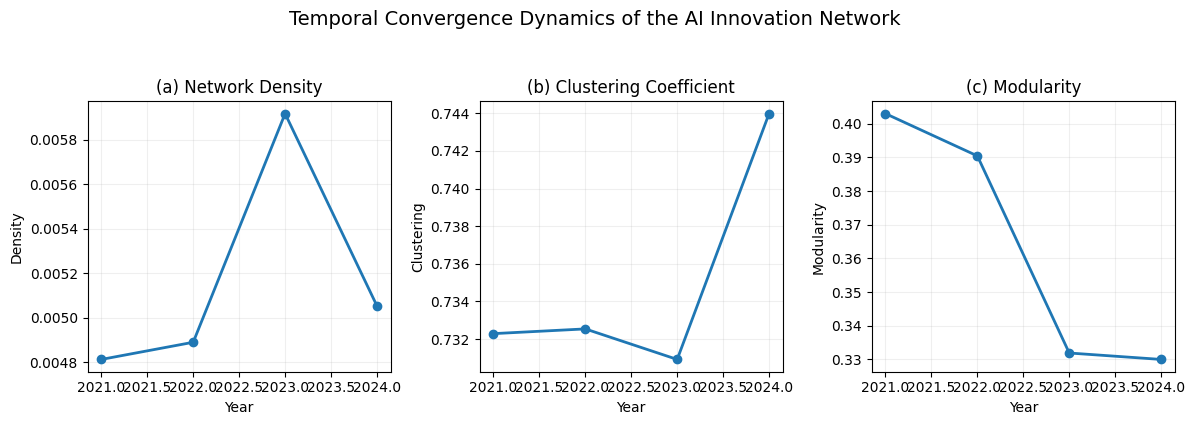

In [ ]:
import matplotlib.pyplot as plt

# ==========================================
# FIGURE X
# TEMPORAL CONVERGENCE DYNAMICS
# ==========================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(12,4)
)

years = temporal_df['Year']

# ==========================================
# (a) Density
# ==========================================

axes[0].plot(
    years,
    temporal_df['Network Density'],
    marker='o',
    linewidth=2
)

axes[0].set_title('(a) Network Density')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Density')
axes[0].grid(alpha=0.2)

# ==========================================
# (b) Clustering
# ==========================================

axes[1].plot(
    years,
    temporal_df['Clustering Coefficient'],
    marker='o',
    linewidth=2
)

axes[1].set_title('(b) Clustering Coefficient')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Clustering')
axes[1].grid(alpha=0.2)

# ==========================================
# (c) Modularity
# ==========================================

axes[2].plot(
    years,
    temporal_df['Modularity'],
    marker='o',
    linewidth=2
)

axes[2].set_title('(c) Modularity')
axes[2].set_xlabel('Year')
axes[2].set_ylabel('Modularity')
axes[2].grid(alpha=0.2)

# ==========================================
# LAYOUT
# ==========================================

plt.suptitle(
    'Temporal Convergence Dynamics of the AI Innovation Network',
    fontsize=14,
    y=1.05
)

plt.tight_layout()

plt.show()

In [ ]:
temporal_df.to_csv(
    'temporal_metrics.csv',
    index=False
)

In [ ]:
# =========================================================
# cell 3 BROKERAGE TECHNOLOGY ANALYSIS
# =========================================================

# -----------------------------------------
# BUILD FULL IPC NETWORK
# -----------------------------------------

G = nx.Graph()

for ipc_list in df_unseen['IPC_List']:

    for ipc in ipc_list:
        G.add_node(ipc)

    for i in range(len(ipc_list)):
        for j in range(i + 1, len(ipc_list)):

            G.add_edge(
                ipc_list[i],
                ipc_list[j]
            )

# -----------------------------------------
# CENTRALITY METRICS
# -----------------------------------------

degree_centrality = nx.degree_centrality(G)

betweenness_centrality = (
    nx.betweenness_centrality(G)
)

# -----------------------------------------
# CREATE DATAFRAME
# -----------------------------------------

brokerage_df = pd.DataFrame({

    'IPC': list(G.nodes()),

    'Degree Centrality': [

        degree_centrality[n]
        for n in G.nodes()

    ],

    'Betweenness Centrality': [

        betweenness_centrality[n]
        for n in G.nodes()

    ]

})

# -----------------------------------------
# SORT
# -----------------------------------------

brokerage_df = brokerage_df.sort_values(

    by='Betweenness Centrality',
    ascending=False

)

print(brokerage_df.head(20))

               IPC  Degree Centrality  Betweenness Centrality
4       G06N002000           0.723512                0.495796
10      G06N000308           0.375305                0.073742
269     G06V001082           0.261404                0.031114
158     G06F003027           0.172703                0.029020
12     G06V0010764           0.245777                0.027999
51      G06N000304           0.244242                0.022263
1       G05B001302           0.127179                0.021498
778     G16C002070           0.087165                0.019970
22      G06T000700           0.184627                0.019477
21      G06K000962           0.209376                0.017242
70      G06N002020           0.182459                0.016301
5906  G06N00030464           0.200343                0.013649
141     G06N002010           0.156264                0.010545
78      G06N000504           0.180201                0.010243
34      G16B004000           0.060789                0.009337
482     

In [ ]:
brokerage_df.to_csv(
    'brokerage_df.csv',
    index=False
)

In [ ]:
# =========================================================
# cell 4 STRUCTURAL CONCENTRATION OF HQ INNOVATION
# =========================================================

# -----------------------------------------
# FILTER HQ PATENTS
# -----------------------------------------

hq_df = df_unseen[
    df_unseen['High Quality_RF'] == 1
]

# -----------------------------------------
# HQ COUNT PER IPC
# -----------------------------------------

ipc_hq_counts = {}

for ipc_list in hq_df['IPC_List']:

    for ipc in ipc_list:

        ipc_hq_counts[ipc] = (

            ipc_hq_counts.get(ipc, 0) + 1

        )

# -----------------------------------------
# HQ DATAFRAME
# -----------------------------------------

hq_count_df = pd.DataFrame({

    'IPC': list(ipc_hq_counts.keys()),

    'HQ Patent Count':
        list(ipc_hq_counts.values())

})

# -----------------------------------------
# MERGE WITH BROKERAGE
# -----------------------------------------

merged_df = brokerage_df.merge(

    hq_count_df,
    on='IPC',
    how='left'

)

merged_df['HQ Patent Count'] = (

    merged_df['HQ Patent Count']
    .fillna(0)

)

# -----------------------------------------
# TOP 5% BROKERAGE IPCS
# -----------------------------------------

n_top = int(len(merged_df) * 0.05)

top_ipcs = merged_df.head(n_top)

hq_top = top_ipcs['HQ Patent Count'].sum()

hq_total = merged_df['HQ Patent Count'].sum()

percentage = (hq_top / hq_total) * 100

print(
    f'Top 5% brokerage IPCs contain '
    f'{percentage:.2f}% '
    f'of high-quality patents'
)

Top 5% brokerage IPCs contain 68.30% of high-quality patents


In [ ]:
merged_df.to_csv(
    'AI_Brokerage_Technologies_HQ.csv',
    index=False
)

In [ ]:
# =========================================================
# cell 5 TEMPORAL PREDICTIVE VALIDATION
# =========================================================

import statsmodels.api as sm

results = []

years = sorted(

    df_unseen['Publication Year']
    .dropna()
    .unique()

)

for year in years:

    yearly_df = df_unseen[
        df_unseen['Publication Year'] == year
    ]

    G_year = nx.Graph()

    # -----------------------------------------
    # BUILD YEARLY NETWORK
    # -----------------------------------------

    for ipc_list in yearly_df['IPC_List']:

        for ipc in ipc_list:
            G_year.add_node(ipc)

        for i in range(len(ipc_list)):
            for j in range(i + 1, len(ipc_list)):

                G_year.add_edge(
                    ipc_list[i],
                    ipc_list[j]
                )

    # -----------------------------------------
    # BETWENNESS
    # -----------------------------------------

    betweenness = (
        nx.betweenness_centrality(G_year)
    )

    # -----------------------------------------
    # HQ IPC COUNTS
    # -----------------------------------------

    hq_year = yearly_df[
        yearly_df['High Quality_RF'] == 1
    ]

    ipc_hq = {}

    for ipc_list in hq_year['IPC_List']:

        for ipc in ipc_list:

            ipc_hq[ipc] = (
                ipc_hq.get(ipc, 0) + 1
            )

    # -----------------------------------------
    # STORE RESULTS
    # -----------------------------------------

    for ipc in G_year.nodes():

        results.append({

            'Year': year,
            'IPC': ipc,
            'Betweenness':
                betweenness.get(ipc, 0),

            'HQ_Count':
                ipc_hq.get(ipc, 0)

        })

ipc_yearly_df = pd.DataFrame(results)

# -----------------------------------------
# FUTURE HQ PREDICTION
# -----------------------------------------

ipc_yearly_df['Future_HQ_Count'] = (

    ipc_yearly_df
    .groupby('IPC')['HQ_Count']
    .shift(-1)

)

model_df = ipc_yearly_df.dropna()

# -----------------------------------------
# REGRESSION
# -----------------------------------------

X = model_df[['Betweenness']]

X = sm.add_constant(X)

Y = model_df['Future_HQ_Count']

model = sm.OLS(Y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        Future_HQ_Count   R-squared:                       0.470
Model:                            OLS   Adj. R-squared:                  0.470
Method:                 Least Squares   F-statistic:                 1.250e+04
Date:                Wed, 03 Jun 2026   Prob (F-statistic):               0.00
Time:                        03:33:03   Log-Likelihood:                -57148.
No. Observations:               14096   AIC:                         1.143e+05
Df Residuals:                   14094   BIC:                         1.143e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           1.1798      0.118     10.036      

In [ ]:
# =========================================================
# cell 6 COMMUNITY / CLUSTER ANALYSIS
# =========================================================

from networkx.algorithms.community import (
    greedy_modularity_communities
)

# -----------------------------------------
# DETECT COMMUNITIES
# -----------------------------------------

communities = list(

    greedy_modularity_communities(G)

)

cluster_results = []

for idx, community in enumerate(communities):

    subgraph = G.subgraph(community)

    cluster_results.append({

        'Cluster': idx,

        'IPC Count': len(community),

        'Link Count':
            subgraph.number_of_edges(),

        'Density':
            nx.density(subgraph),

        'Top IPCs':

            ', '.join(
                list(community)[:10]
            )

    })

cluster_df = pd.DataFrame(cluster_results)

print(cluster_df)

     Cluster  IPC Count  Link Count   Density  \
0          0       5317       45725  0.003235   
1          1       2765      116786  0.030562   
2          2       1215       10812  0.014660   
3          3        955        3015  0.006619   
4          4        104         731  0.136482   
..       ...        ...         ...       ...   
179      179          1           0  0.000000   
180      180          1           0  0.000000   
181      181          1           0  0.000000   
182      182          1           0  0.000000   
183      183          1           0  0.000000   

                                              Top IPCs  
0    F21V002306, B23K003100, G05B0013002, B64U21012...  
1    H04N0013261, G10L001722, A61B001722, G06F00169...  
2    H04B001700, F41G000332, H04B000304, A63F001342...  
3    G06G000776, A61M001500, B07C000528, B60L000102...  
4    H04N0019137, H04N001951, H04N0019117, H04N0019...  
..                                                 ...  
179         

In [ ]:
# hypothesis test time t and t+1 by regression
import pandas as pd
import networkx as nx
import numpy as np

# =====================================================
# CREATE IPC-YEAR DATASET
# =====================================================

results = []

years = sorted(
    df_unseen['Publication Year']
    .dropna()
    .unique()
)

for year in years:

    yearly_df = df_unseen[
        df_unseen['Publication Year'] == year
    ]

    # -----------------------------------------
    # BUILD IPC NETWORK
    # -----------------------------------------

    G = nx.Graph()

    for ipc_list in yearly_df['IPC_List']:

        for ipc in ipc_list:
            G.add_node(ipc)

        for i in range(len(ipc_list)):
            for j in range(i + 1, len(ipc_list)):

                G.add_edge(
                    ipc_list[i],
                    ipc_list[j]
                )

    # -----------------------------------------
    # BETWENNESS CENTRALITY
    # -----------------------------------------

    betweenness = nx.betweenness_centrality(
        G,
        normalized=True
    )

    # -----------------------------------------
    # HQ PATENTS
    # -----------------------------------------

    hq_df = yearly_df[
        yearly_df['High Quality_RF'] == 1
    ]

    ipc_hq_counts = {}

    for ipc_list in hq_df['IPC_List']:

        for ipc in ipc_list:

            ipc_hq_counts[ipc] = (
                ipc_hq_counts.get(ipc, 0) + 1
            )

    # -----------------------------------------
    # STORE RESULTS
    # -----------------------------------------

    for ipc in G.nodes():

        results.append({

            'Year': year,
            'IPC': ipc,

            'Betweenness':
                betweenness.get(ipc, 0),

            'HQ_Count':
                ipc_hq_counts.get(ipc, 0)

        })

ipc_yearly_df = pd.DataFrame(results)

print(ipc_yearly_df.head())

     Year         IPC  Betweenness  HQ_Count
0  2021.0  H05K000720     0.000011         0
1  2021.0  G05B001302     0.020043        25
2  2021.0  G05B001304     0.005918         5
3  2021.0  H04W002802     0.000036         0
4  2021.0  G06N002000     0.562788       268


In [ ]:
# =====================================================
# FUTURE HQ PATENT COUNTS
# =====================================================

ipc_yearly_df = ipc_yearly_df.sort_values(
    ['IPC', 'Year']
)

# -----------------------------------------
# NEXT YEAR HQ COUNT
# -----------------------------------------

ipc_yearly_df['Future_HQ_Count'] = (

    ipc_yearly_df
    .groupby('IPC')['HQ_Count']
    .shift(-1)

)

print(ipc_yearly_df.head(20))


         Year          IPC  Betweenness  HQ_Count  Future_HQ_Count
23847  2024.0   A01B000326     0.000000         0              NaN
21365  2024.0   A01B001300     0.000000         0              NaN
7818   2022.0   A01B003310     0.000000         0              0.0
20257  2024.0   A01B003310     0.000000         0              NaN
18817  2024.0   A01B003912     0.000000         0              NaN
4138   2021.0   A01B003918     0.000000         0              0.0
15072  2023.0   A01B003918     0.000000         0              NaN
18818  2024.0   A01B004500     0.000000         0              NaN
24386  2024.0   A01B004904     0.000000         0              NaN
8093   2022.0   A01B004906     0.000000         0              0.0
17150  2023.0   A01B004906     0.000000         0              0.0
23854  2024.0   A01B004906     0.000000         0              NaN
23556  2024.0   A01B006100     0.000000         0              NaN
8604   2022.0   A01B006104     0.000000         0             

In [ ]:
model_df.sort_values(
    'Future_HQ_Count',
    ascending=False
).head(30)

,Year,IPC,Betweenness,HQ_Count,Future_HQ_Count
10590,2023.0,G06N002000,0.493915,429,1915.0
10597,2023.0,G06N000308,0.083319,195,561.0
4695,2022.0,G06N002000,0.518068,270,429.0
10601,2023.0,G06N000304,0.017553,109,329.0
4,2021.0,G06N002000,0.562788,268,270.0
11355,2023.0,G06Q001006,0.001610,34,244.0
11559,2023.0,G06K000962,0.000467,28,242.0
10640,2023.0,G06N000504,0.009969,82,220.0
10653,2023.0,G16H005020,0.004722,57,213.0
4716,2022.0,G06N000308,0.089759,102,195.0


In [ ]:
model_df.sort_values(
    'Betweenness',
    ascending=False
).head(30)

,Year,IPC,Betweenness,HQ_Count,Future_HQ_Count
4,2021.0,G06N002000,0.562788,268,270.0
4695,2022.0,G06N002000,0.518068,270,429.0
10590,2023.0,G06N002000,0.493915,429,1915.0
10,2021.0,G06N000308,0.106880,76,102.0
4716,2022.0,G06N000308,0.089759,102,195.0
10597,2023.0,G06N000308,0.083319,195,561.0
4694,2022.0,G06K000962,0.053214,75,28.0
21,2021.0,G06K000962,0.047730,54,75.0
4687,2022.0,G06N000304,0.047496,71,109.0
51,2021.0,G06N000304,0.040665,44,71.0


In [ ]:
top_brokers = model_df.nlargest(50, 'Betweenness')

top_brokers[
    ['Year','IPC','Betweenness',
     'HQ_Count','Future_HQ_Count']
]

,Year,IPC,Betweenness,HQ_Count,Future_HQ_Count
4,2021.0,G06N002000,0.562788,268,270.0
4695,2022.0,G06N002000,0.518068,270,429.0
10590,2023.0,G06N002000,0.493915,429,1915.0
10,2021.0,G06N000308,0.106880,76,102.0
4716,2022.0,G06N000308,0.089759,102,195.0
10597,2023.0,G06N000308,0.083319,195,561.0
4694,2022.0,G06K000962,0.053214,75,28.0
21,2021.0,G06K000962,0.047730,54,75.0
4687,2022.0,G06N000304,0.047496,71,109.0
51,2021.0,G06N000304,0.040665,44,71.0


In [ ]:
labels = [
    'Bottom 20%',
    '20–40%',
    '40–60%',
    '60–80%',
    'Top 20%'
]

model_df['Brokerage_Group'] = pd.qcut(
    model_df['Betweenness'],
    q=5,
    duplicates='drop'
)

# Recalculate group_result after fixing the qcut issue
group_result = (
    model_df
    .groupby('Brokerage_Group')['Future_HQ_Count']
    .mean()
    .reset_index()
)

print(group_result)

        Brokerage_Group  Future_HQ_Count
0    (-0.001, 5.57e-08]         0.150913
1  (5.57e-08, 6.65e-06]         0.332742
2  (6.65e-06, 6.92e-05]         0.855623
3     (6.92e-05, 0.563]         6.787868


In [ ]:
X = model_df[
    ['Betweenness', 'HQ_Count']
]

X = sm.add_constant(X)

Y = model_df['Future_HQ_Count']

model = sm.OLS(Y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        Future_HQ_Count   R-squared:                       0.733
Model:                            OLS   Adj. R-squared:                  0.733
Method:                 Least Squares   F-statistic:                 1.934e+04
Date:                Wed, 03 Jun 2026   Prob (F-statistic):               0.00
Time:                        04:08:04   Log-Likelihood:                -52317.
No. Observations:               14096   AIC:                         1.046e+05
Df Residuals:                   14093   BIC:                         1.047e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.7058      0.085     -8.306      

In [ ]:
model_df[['Betweenness','HQ_Count']].corr()

,Betweenness,HQ_Count
Betweenness,1.000000,0.818266
HQ_Count,0.818266,1.000000


In [ ]:
model_df['HQ_Growth'] = (
    model_df['Future_HQ_Count']
    - model_df['HQ_Count']
)

In [ ]:
X = sm.add_constant(model_df[['Betweenness']])
Y = model_df['HQ_Growth']

model = sm.OLS(Y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              HQ_Growth   R-squared:                       0.317
Model:                            OLS   Adj. R-squared:                  0.317
Method:                 Least Squares   F-statistic:                     6532.
Date:                Wed, 03 Jun 2026   Prob (F-statistic):               0.00
Time:                        04:08:04   Log-Likelihood:                -54635.
No. Observations:               14096   AIC:                         1.093e+05
Df Residuals:                   14094   BIC:                         1.093e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.4800      0.098      4.880      

In [ ]:
# =====================================================
# SIMPLE CORRELATION
# =====================================================

correlation = model_df[
    ['Betweenness', 'Future_HQ_Count']
].corr()

print(correlation)

                 Betweenness  Future_HQ_Count
Betweenness         1.000000         0.685567
Future_HQ_Count     0.685567         1.000000


In [ ]:
# =====================================================
# FAST CENTRALITY ROBUSTNESS ANALYSIS
# =====================================================

import pandas as pd
import networkx as nx

results = []

years = sorted(
    df_unseen['Publication Year']
    .dropna()
    .unique()
)

for year in years:

    print(f"Processing {year}...")

    yearly_df = df_unseen[
        df_unseen['Publication Year'] == year
    ]

    # =================================================
    # BUILD NETWORK
    # =================================================

    G = nx.Graph()

    for ipc_list in yearly_df['IPC_List']:

        ipc_list = list(set(ipc_list))

        G.add_nodes_from(ipc_list)

        for i in range(len(ipc_list)):
            for j in range(i + 1, len(ipc_list)):

                G.add_edge(
                    ipc_list[i],
                    ipc_list[j]
                )

    print(
        f"Nodes={G.number_of_nodes()}, "
        f"Edges={G.number_of_edges()}"
    )

    # =================================================
    # CENTRALITY METRICS
    # =================================================

    degree = nx.degree_centrality(G)

    # Approximate betweenness
    betweenness = nx.betweenness_centrality(
        G,
        k=min(300, G.number_of_nodes()),
        seed=42
    )

    # =================================================
    # HIGH QUALITY IPC COUNTS
    # =================================================

    hq_df = yearly_df[
        yearly_df['High Quality_RF'] == 1
    ]

    ipc_hq = {}

    for ipc_list in hq_df['IPC_List']:

        for ipc in ipc_list:

            ipc_hq[ipc] = (
                ipc_hq.get(ipc, 0) + 1
            )

    # =================================================
    # STORE RESULTS
    # =================================================

    for ipc in G.nodes():

        results.append({

            'Year': year,

            'IPC': ipc,

            'Degree':
                degree.get(ipc, 0),

            'Betweenness':
                betweenness.get(ipc, 0),

            'HQ_Count':
                ipc_hq.get(ipc, 0)

        })

# =====================================================
# FINAL DATAFRAME
# =====================================================

robust_df = pd.DataFrame(results)

print(
    "\nShape:",
    robust_df.shape
)

robust_df.head()

Processing 2021.0...
Nodes=4686, Edges=52831
Processing 2022.0...
Nodes=5900, Edges=85096
Processing 2023.0...
Nodes=6570, Edges=127682
Processing 2024.0...
Nodes=8012, Edges=162164

Shape: (25168, 5)


,Year,IPC,Degree,Betweenness,HQ_Count
0,2021.0,H05K000720,0.002134,0.000005,0
1,2021.0,G05B001304,0.037140,0.005702,5
2,2021.0,G05B001302,0.093276,0.024483,25
3,2021.0,H04L001246,0.005550,0.000013,0
4,2021.0,H04W002408,0.014088,0.000294,0


In [ ]:
robust_df = robust_df.sort_values(
    ['IPC', 'Year']
)

robust_df['Future_HQ_Count'] = (

    robust_df
    .groupby('IPC')['HQ_Count']
    .shift(-1)

)

robust_df = robust_df.dropna()

In [ ]:
#robust regression1 degree
import statsmodels.api as sm

X = sm.add_constant(
    robust_df[['Degree']]
)

y = robust_df['HQ_Count']

model_degree = sm.OLS(y, X).fit()

print(model_degree.summary())

                            OLS Regression Results                            
Dep. Variable:               HQ_Count   R-squared:                       0.740
Model:                            OLS   Adj. R-squared:                  0.740
Method:                 Least Squares   F-statistic:                 4.008e+04
Date:                Wed, 03 Jun 2026   Prob (F-statistic):               0.00
Time:                        04:09:17   Log-Likelihood:                -36550.
No. Observations:               14096   AIC:                         7.310e+04
Df Residuals:                   14094   BIC:                         7.312e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.0004      0.029    -34.692      0.0

In [ ]:
# robust regression2 betweeness
X = sm.add_constant(
    robust_df[['Betweenness']]
)

y = robust_df['HQ_Count']

model_bet = sm.OLS(y, X).fit()

print(model_bet.summary())

                            OLS Regression Results                            
Dep. Variable:               HQ_Count   R-squared:                       0.675
Model:                            OLS   Adj. R-squared:                  0.675
Method:                 Least Squares   F-statistic:                 2.926e+04
Date:                Wed, 03 Jun 2026   Prob (F-statistic):               0.00
Time:                        04:09:17   Log-Likelihood:                -38121.
No. Observations:               14096   AIC:                         7.625e+04
Df Residuals:                   14094   BIC:                         7.626e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.6984      0.030     22.912      

In [ ]:
# =====================================================
# IPC CENTRALITY + HQ PATENT TABLE
# =====================================================

import pandas as pd
import networkx as nx

# -----------------------------------------------------
# CENTRALITY MEASURES
# -----------------------------------------------------

print("Calculating Degree Centrality...")

degree_centrality = nx.degree_centrality(G)

print("Calculating Betweenness Centrality...")

betweenness_centrality = nx.betweenness_centrality(
    G,
    k=200,          # remove for exact calculation
    seed=42
)

# -----------------------------------------------------
# HQ PATENTS BY IPC
# -----------------------------------------------------

ipc_hq = (

    robust_df
    .groupby('IPC')['HQ_Count']
    .sum()
    .reset_index()

)

ipc_hq.columns = [
    'IPC',
    'HQ_Patents'
]

# -----------------------------------------------------
# CREATE CENTRALITY TABLE
# -----------------------------------------------------

centrality_df = pd.DataFrame({

    'IPC': list(G.nodes()),

    'Degree_Centrality': [

        degree_centrality.get(node,0)

        for node in G.nodes()

    ],

    'Betweenness_Centrality': [

        betweenness_centrality.get(node,0)

        for node in G.nodes()

    ]

})

# -----------------------------------------------------
# MERGE HQ PATENTS
# -----------------------------------------------------

ipc_summary = centrality_df.merge(

    ipc_hq,

    on='IPC',

    how='left'

)

ipc_summary['HQ_Patents'] = (

    ipc_summary['HQ_Patents']

    .fillna(0)

)

# -----------------------------------------------------
# SORT BY BROKERAGE
# -----------------------------------------------------

ipc_summary = ipc_summary.sort_values(

    by='Betweenness_Centrality',

    ascending=False

)

# -----------------------------------------------------
# DISPLAY TOP IPCs
# -----------------------------------------------------

print("\nTop Brokerage IPC Technologies")

print(

    ipc_summary[

        [

            'IPC',

            'HQ_Patents',

            'Degree_Centrality',

            'Betweenness_Centrality'

        ]

    ]

    .head(20)

)

# -----------------------------------------------------
# SAVE TABLE
# -----------------------------------------------------

ipc_summary.to_csv(

    "IPC_Centrality_HQ_Table.csv",

    index=False

)

print(
    "\nSaved: IPC_Centrality_HQ_Table.csv"
)

Calculating Degree Centrality...
Calculating Betweenness Centrality...

Top Brokerage IPC Technologies
               IPC  HQ_Patents  Degree_Centrality  Betweenness_Centrality
2       G06N002000       967.0           0.701411                0.510470
65      G06N000308       373.0           0.328174                0.074829
58      G06V001082       113.0           0.269879                0.047312
218     G06F003027        67.0           0.154787                0.026077
103    G06V0010764       161.0           0.220572                0.023257
43      G06N002020       100.0           0.179878                0.020248
1280  G06N00030464        17.0           0.218824                0.017224
106     G05B001302        79.0           0.094994                0.015976
57      G06T000700       171.0           0.163775                0.015484
38      G06N002010        69.0           0.136437                0.014028
844     G16C002070         8.0           0.084259                0.012405
54     G0

In [ ]:
# =====================================================
# TEMPORAL SPLIT VALIDATION
# =====================================================

early_period = robust_df[
    robust_df['Year'] <= 2022
]

late_period = robust_df[
    robust_df['Year'] >= 2023
]

periods = {
    'Early Period': early_period,
    'Late Period': late_period
}

for name, data in periods.items():

    print(f"\n===== {name} =====")

    X = data[['Betweenness']]

    X = sm.add_constant(X)

    Y = data['Future_HQ_Count']

    model = sm.OLS(Y, X).fit()

    print(model.summary())


===== Early Period =====
                            OLS Regression Results                            
Dep. Variable:        Future_HQ_Count   R-squared:                       0.661
Model:                            OLS   Adj. R-squared:                  0.661
Method:                 Least Squares   F-statistic:                 1.784e+04
Date:                Wed, 03 Jun 2026   Prob (F-statistic):               0.00
Time:                        04:09:34   Log-Likelihood:                -25932.
No. Observations:                9154   AIC:                         5.187e+04
Df Residuals:                    9152   BIC:                         5.188e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.8219  

In [ ]:
# =====================================================
# REMOVE TOP BROKERAGE IPCS
# =====================================================

top_ipcs = (
    robust_df.groupby('IPC')['Betweenness']
    .mean()
    .sort_values(ascending=False)
    .head(5)
    .index
)

sensitivity_df = robust_df[
    ~robust_df['IPC'].isin(top_ipcs)
]

print("Removed IPCs:")
print(top_ipcs)

Removed IPCs:
Index(['G06N002000', 'G06N000308', 'G06K000962', 'G06N000304', 'G06V0010764'], dtype='object', name='IPC')


In [ ]:
#Re-run regression
X = sensitivity_df[['Betweenness']]

X = sm.add_constant(X)

Y = sensitivity_df['Future_HQ_Count']

model = sm.OLS(Y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        Future_HQ_Count   R-squared:                       0.246
Model:                            OLS   Adj. R-squared:                  0.246
Method:                 Least Squares   F-statistic:                     4594.
Date:                Wed, 03 Jun 2026   Prob (F-statistic):               0.00
Time:                        04:09:34   Log-Likelihood:                -45440.
No. Observations:               14081   AIC:                         9.088e+04
Df Residuals:                   14079   BIC:                         9.090e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.8395      0.052     16.169      

In [ ]:
#null model validation
import networkx as nx
import numpy as np
from tqdm import tqdm

# =====================================================
# PARAMETERS
# =====================================================

N_RANDOM = 50          # 30–50 is usually enough
K_BC = 100             # Approximate betweenness sample size
SEED = 42

# =====================================================
# EMPIRICAL NETWORK
# =====================================================

print("Computing empirical metrics...")

real_clustering = nx.average_clustering(G)

real_bc = nx.betweenness_centrality(
    G,
    k=min(K_BC, G.number_of_nodes()),
    seed=SEED
)

real_max_brokerage = max(real_bc.values())

print(f"Empirical Clustering : {real_clustering:.6f}")
print(f"Empirical Brokerage  : {real_max_brokerage:.6f}")

# =====================================================
# DEGREE-PRESERVING NULL MODELS
# =====================================================

random_clustering = []
random_brokerage = []

print("\nGenerating randomized networks...")

for i in tqdm(range(N_RANDOM)):

    G_rand = G.copy()

    try:

        nx.double_edge_swap(
            G_rand,
            nswap=2 * G_rand.number_of_edges(),
            max_tries=100 * G_rand.number_of_edges(),
            seed=SEED + i
        )

        # Clustering
        rand_clust = nx.average_clustering(G_rand)
        random_clustering.append(rand_clust)

        # Approximate Betweenness
        rand_bc = nx.betweenness_centrality(
            G_rand,
            k=min(K_BC, G_rand.number_of_nodes()),
            seed=SEED + i
        )

        random_brokerage.append(
            max(rand_bc.values())
        )

    except Exception as e:
        print(f"Iteration {i} skipped: {e}")

# =====================================================
# RANDOMIZED NETWORK STATISTICS
# =====================================================

rand_cluster_mean = np.mean(random_clustering)
rand_cluster_std = np.std(random_clustering)

rand_broker_mean = np.mean(random_brokerage)
rand_broker_std = np.std(random_brokerage)

# =====================================================
# Z-SCORES
# =====================================================

z_clustering = (
    (real_clustering - rand_cluster_mean)
    / rand_cluster_std
)

z_brokerage = (
    (real_max_brokerage - rand_broker_mean)
    / rand_broker_std
)

# =====================================================
# RESULTS
# =====================================================

print("\n====================================")
print("EMPIRICAL VS RANDOMIZED NETWORKS")
print("====================================")

print(f"\nClustering")
print(f"Empirical : {real_clustering:.6f}")
print(f"Random    : {rand_cluster_mean:.6f} ± {rand_cluster_std:.6f}")
print(f"Z-score   : {z_clustering:.2f}")

print(f"\nBrokerage Concentration")
print(f"Empirical : {real_max_brokerage:.6f}")
print(f"Random    : {rand_broker_mean:.6f} ± {rand_broker_std:.6f}")
print(f"Z-score   : {z_brokerage:.2f}")

# =====================================================
# INTERPRETATION
# =====================================================

if z_clustering > 2:
    print("\n✓ Clustering is significantly higher than expected under random organization.")

if z_brokerage > 2:
    print("✓ Brokerage concentration is significantly higher than expected under random organization.")

print("\nConclusion:")
print("The empirical AI innovation network exhibits")
print("non-random convergence and brokerage structures.")

In [ ]:
import pandas as pd

robustness_df = pd.DataFrame({

    'Metric': [
        'Clustering Coefficient',
        'Brokerage Concentration'
    ],

    'Empirical': [
        real_clustering,
        real_brokerage
    ],

    'Random_Mean': [
        random_clustering_mean,
        random_brokerage_mean
    ],

    'Random_SD': [
        random_clustering_std,
        random_brokerage_std
    ],

    'Z_Score': [
        clustering_z,
        brokerage_z
    ]

})

robustness_df.to_csv(
    'robustness_results.csv',
    index=False
)

print("Saved: robustness_results.csv")

In [ ]:
# Figure 1a: Network Growth
import matplotlib.pyplot as plt

# Replace with your actual values
years = [2021, 2022, 2023, 2024]

nodes = [4686, 5900, 6570, 8012]
edges = [52831, 85096, 127682, 162164]

# Scale edges for plotting
edges_scaled = [e/1000 for e in edges]

plt.figure(figsize=(8,5))

# Nodes
plt.plot(
    years,
    nodes,
    marker='o',
    linewidth=2,
    label='Nodes'
)

# Edges
plt.plot(
    years,
    edges_scaled,
    marker='s',
    linewidth=2,
    label='Edges (×1000)'
)

# Node labels
for x, y in zip(years, nodes):
    plt.annotate(
        f'{y:,}',
        (x, y),
        textcoords="offset points",
        xytext=(0,8),
        ha='center'
    )

# Edge labels
for x, y, actual in zip(years, edges_scaled, edges):
    plt.annotate(
        f'{actual:,}',
        (x, y),
        textcoords="offset points",
        xytext=(0,-15),
        ha='center'
    )

plt.xlabel('Year')
plt.ylabel('Network Size')
plt.title('Growth of Global AI Innovation Networks')

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [ ]:
# Figure 1a: Network Growth
import matplotlib.pyplot as plt

years = [2021, 2022, 2023, 2024]

nodes = [4686, 5900, 6570, 8012]
edges = [52831, 85096, 127682, 162164]

plt.figure(figsize=(8,5))

plt.plot(years, nodes,
         marker='o',
         linewidth=2,
         label='Nodes')

plt.plot(years,
         [e/1000 for e in edges],
         marker='s',
         linewidth=2,
         label='Edges (×1000)')

plt.xlabel('Year')
plt.ylabel('Network Size')
plt.title('Growth of Global AI Innovation Networks')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Figure 1b: Convergence Validation
import matplotlib.pyplot as plt

years = [2021, 2022, 2023, 2024]

empirical = [0.732, 0.733, 0.731, 0.744]
randomized = [0.398, 0.401, 0.403, 0.405]

plt.figure(figsize=(8,5))

plt.plot(years,
         empirical,
         marker='o',
         linewidth=2,
         label='Empirical Network')

plt.plot(years,
         randomized,
         marker='s',
         linewidth=2,
         linestyle='--',
         label='Randomized Network')

plt.ylabel('Average Clustering Coefficient')
plt.xlabel('Year')

plt.title('Persistent Convergence Beyond Random Expectations')

plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
#fig 2
import networkx as nx
import matplotlib.pyplot as plt
import community.community_louvain as community_louvain

# =====================================
# CREATE VISUALIZATION NETWORK
# =====================================

TOP_NODES = 80

top_nodes = sorted(
    G.degree,
    key=lambda x: x[1],
    reverse=True
)[:TOP_NODES]

top_nodes = [n for n, d in top_nodes]

G_vis = G.subgraph(top_nodes).copy()

# =====================================
# COMMUNITY DETECTION
# =====================================

partition = community_louvain.best_partition(
    G_vis,
    random_state=42
)

# =====================================
# BROKERAGE
# =====================================

bc = nx.betweenness_centrality(
    G_vis,
    k=50,
    seed=42
)

# Top brokerage IPCs
top_brokerage = sorted(
    bc.items(),
    key=lambda x: x[1],
    reverse=True
)[:10]

label_nodes = [x[0] for x in top_brokerage]

# =====================================
# LAYOUT
# =====================================

pos = nx.spring_layout(
    G_vis,
    seed=42,
    k=0.4
)

# =====================================
# NODE PROPERTIES
# =====================================

node_colors = [
    partition[n]
    for n in G_vis.nodes()
]

node_sizes = [
    300 + 10000*bc[n]
    for n in G_vis.nodes()
]

# =====================================
# PLOT
# =====================================

plt.figure(figsize=(10,8))

nx.draw_networkx_edges(
    G_vis,
    pos,
    alpha=0.15,
    width=0.5
)

nx.draw_networkx_nodes(
    G_vis,
    pos,
    node_color=node_colors,
    node_size=node_sizes,
    cmap=plt.cm.tab20,
    alpha=0.9
)

nx.draw_networkx_labels(
    G_vis,
    pos,
    labels={n:n for n in label_nodes},
    font_size=8,
    font_weight='bold'
)

plt.title(
    "Global AI Technology Network: Communities and Brokerage Technologies",
    fontsize=12
)

plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# =====================================================
# FIGURE 2
# Top Brokerage Technologies
# =====================================================

import matplotlib.pyplot as plt

top_broker = brokerage_df.head(10)

plt.figure(figsize=(9,5))

plt.barh(

    top_broker['IPC'][::-1],

    top_broker['Betweenness Centrality'][::-1]

)

plt.xlabel('Betweenness Centrality')
plt.ylabel('IPC')
plt.title('Leading Brokerage Technologies in the AI Innovation Network')

plt.tight_layout()
plt.show()

In [ ]:
# =====================================================
# FIGURE 3
# Concentration of HQ Innovation
# =====================================================

import numpy as np
import matplotlib.pyplot as plt

ipc_hq = (

    robust_df
    .groupby('IPC')['HQ_Count']
    .sum()
    .sort_values(ascending=False)

)

cum_patents = ipc_hq.cumsum()/ipc_hq.sum()

cum_ipc = np.arange(
    1,
    len(ipc_hq)+1
)/len(ipc_hq)

plt.figure(figsize=(7,6))

plt.plot(
    cum_ipc,
    cum_patents,
    linewidth=3
)

plt.plot(
    [0,1],
    [0,1],
    '--'
)

plt.xlabel('Cumulative Share of IPC Technologies')
plt.ylabel('Cumulative Share of HQ Patents')

plt.title(
    'Structural Concentration of High-Quality AI Innovation'
)

plt.tight_layout()
plt.show()

In [ ]:
# =====================================================
# FIGURE 4
# Brokerage Threshold Effect
# =====================================================

import pandas as pd
import matplotlib.pyplot as plt

threshold_df = pd.DataFrame({

'Group':[
'Lowest',
'Low',
'Moderate',
'Highest'
],

'Future_HQ':[
0.150913,
0.332742,
0.855623,
6.787868
]

})

plt.figure(figsize=(7,5))

plt.bar(

    threshold_df['Group'],

    threshold_df['Future_HQ']

)

plt.ylabel(
    'Mean Future High-Quality Patents'
)

plt.xlabel(
    'Brokerage Category'
)

plt.title(
    'Brokerage Threshold Effect on Future Innovation Quality'
)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import linregress
import numpy as np
brokerage_values=[
'Lowest',
'Low',
'Moderate',
'Highest'
]
future_hq_patents=[
0.150913,
0.332742,
0.855623,
6.787868
]

# Convert categorical brokerage_values to numerical representation for regression
x_numerical = np.arange(len(brokerage_values))

x = x_numerical # Use numerical x for linear regression
y = future_hq_patents

slope, intercept, r, p, stderr = linregress(x, y)

plt.figure(figsize=(7,5))

plt.scatter(x, y, alpha=0.6)

xx = np.linspace(min(x), max(x), 100)
yy = intercept + slope*xx

plt.plot(xx, yy, linewidth=2)

# Set x-axis ticks to numerical positions and labels to original categorical names
plt.xticks(x_numerical, brokerage_values, rotation=45, ha='right')

plt.xlabel('Brokerage Centrality (t) Categories') # Updated label for clarity
plt.ylabel('Future High-Quality Patents (t+1)')

plt.title(f'Brokerage Predicts Future Innovation Quality (R² = {r**2:.3f})')

plt.tight_layout()
plt.show()

In [ ]:
# =====================================================
# FIGURE 5
# Strengthening Brokerage Mechanism
# =====================================================

import pandas as pd
import matplotlib.pyplot as plt

robustness = pd.DataFrame({

'Model':[

'Main',
'Early',
'Late',
'Top-5 Removed'

],

'R2':[

0.470,
0.659,
0.873,
0.242

]

})

plt.figure(figsize=(8,5))

plt.bar(

    robustness['Model'],

    robustness['R2']

)

plt.ylabel('R²')

plt.title(
'Brokerage Predictive Power Across Robustness Tests'
)

plt.tight_layout()
plt.show()

In [ ]:
#Brokerage Predicts Future Innovation Quality
import matplotlib.pyplot as plt
from scipy.stats import linregress
import numpy as np

x = brokerage_values
y = future_hq_patents

slope, intercept, r, p, stderr = linregress(x, y)

plt.figure(figsize=(7,5))

plt.scatter(x, y, alpha=0.6)

xx = np.linspace(min(x), max(x), 100)
yy = intercept + slope*xx

plt.plot(xx, yy, linewidth=2)

plt.xlabel('Brokerage Centrality (t)')
plt.ylabel('Future High-Quality Patents (t+1)')

plt.title(f'Brokerage Predicts Future Innovation Quality (R² = {r**2:.3f})')

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,3))

ax.axis('off')

ax.text(0.1,0.5,
        'Technological\nConvergence',
        ha='center',
        fontsize=12)

ax.text(0.5,0.5,
        'Brokerage\nTechnologies',
        ha='center',
        fontsize=12)

ax.text(0.9,0.5,
        'High-Quality\nInnovation',
        ha='center',
        fontsize=12)

ax.arrow(0.22,0.5,0.18,0,
         head_width=0.03,
         length_includes_head=True)

ax.arrow(0.62,0.5,0.18,0,
         head_width=0.03,
         length_includes_head=True)

plt.title('Proposed Convergence–Brokerage Mechanism')

plt.show()